Proyecto Procesamiento de Datos - Entrega 1

In [16]:
pip install pyspark


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\ususario\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.ticker import ScalarFormatter
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

In [18]:
spark = SparkSession.builder.appName("proyecto_1").getOrCreate()

In [19]:
icfes=spark.read.csv(r"C:\Users\ususario\Documents\Universidad\Noveno Semestre\Procesamiento de datos\Resultados_únicos_Saber_11_20260403.csv", header=True, inferSchema=True)
internet=spark.read.csv(r"C:\Users\ususario\Documents\Universidad\Noveno Semestre\Procesamiento de datos\Internet_Fijo_Accesos_por_tecnología_y_segmento_20260403.csv", header=True, inferSchema=True)

In [20]:
import os
os.makedirs("outputs_eda", exist_ok=True)
os.makedirs("outputs_eda/plots", exist_ok=True)
os.makedirs("outputs_eda/tables", exist_ok=True)

In [21]:
icfes.printSchema()

root
 |-- PERIODO: integer (nullable = true)
 |-- ESTU_TIPODOCUMENTO: string (nullable = true)
 |-- ESTU_CONSECUTIVO: string (nullable = true)
 |-- COLE_AREA_UBICACION: string (nullable = true)
 |-- COLE_BILINGUE: string (nullable = true)
 |-- COLE_CALENDARIO: string (nullable = true)
 |-- COLE_CARACTER: string (nullable = true)
 |-- COLE_COD_DANE_ESTABLECIMIENTO: long (nullable = true)
 |-- COLE_COD_DANE_SEDE: long (nullable = true)
 |-- COLE_COD_DEPTO_UBICACION: integer (nullable = true)
 |-- COLE_COD_MCPIO_UBICACION: integer (nullable = true)
 |-- COLE_CODIGO_ICFES: integer (nullable = true)
 |-- COLE_DEPTO_UBICACION: string (nullable = true)
 |-- COLE_GENERO: string (nullable = true)
 |-- COLE_JORNADA: string (nullable = true)
 |-- COLE_MCPIO_UBICACION: string (nullable = true)
 |-- COLE_NATURALEZA: string (nullable = true)
 |-- COLE_NOMBRE_ESTABLECIMIENTO: string (nullable = true)
 |-- COLE_NOMBRE_SEDE: string (nullable = true)
 |-- COLE_SEDE_PRINCIPAL: string (nullable = true)
 |

In [22]:
schema_icfes = pd.DataFrame(
    [(f.name, str(f.dataType), f.nullable) for f in icfes.schema.fields],
    columns=["columna", "tipo", "nullable"]
)
schema_icfes.to_csv("outputs_eda/tables/schema_icfes.csv", index=False)

In [23]:
pdf = (
    icfes.groupBy("PERIODO")
    .count()
    .orderBy("PERIODO")
    .toPandas()
)

plt.figure(figsize=(12,6))
plt.bar(pdf["PERIODO"].astype(str), pdf["count"])

ax = plt.gca()
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style='plain', axis='y')

plt.xticks(rotation=90)
plt.title("Cantidad de registros ICFES por periodo")
plt.xlabel("Periodo")
plt.ylabel("Número de registros")
plt.tight_layout()
plt.savefig("outputs_eda/plots/g1_icfes_registros_por_periodo.png", dpi=300)
plt.close()

In [24]:
internet.printSchema()

root
 |-- AÑO: integer (nullable = true)
 |-- TRIMESTRE: integer (nullable = true)
 |-- PROVEEDOR: string (nullable = true)
 |-- COD_DEPARTAMENTO: integer (nullable = true)
 |-- DEPARTAMENTO: string (nullable = true)
 |-- COD_MUNICIPIO: integer (nullable = true)
 |-- MUNICIPIO: string (nullable = true)
 |-- SEGMENTO: string (nullable = true)
 |-- TECNOLOGIA: string (nullable = true)
 |-- VELOCIDAD_BAJADA: string (nullable = true)
 |-- VELOCIDAD_SUBIDA: string (nullable = true)
 |-- No DE ACCESOS: integer (nullable = true)



In [25]:
schema_internet = pd.DataFrame(
    [(f.name, str(f.dataType), f.nullable) for f in internet.schema.fields],
    columns=["columna", "tipo", "nullable"]
)
schema_internet.to_csv("outputs_eda/tables/schema_internet.csv", index=False)

In [26]:
icfes.summary().show()

+-------+------------------+------------------+------------------+-------------------+-------------+---------------+-----------------+-----------------------------+--------------------+------------------------+------------------------+------------------+--------------------+-----------+------------+--------------------+---------------+---------------------------+--------------------+-------------------+---------------------------+---------------------------+---------------------+---------------------+-----------------------+-----------------+------------------------+---------------+--------------------+-----------+-----------------------+-----------------+-----------------+----------------+---------------------+-----------------+--------------------+--------------------+--------------------+------------------+-------------------+--------------------+------------------+------------------+-------------+------------------+------------------+------------------------+------------------+----

In [27]:
internet.summary().show()

+-------+------------------+------------------+--------------------+-----------------+------------+------------------+---------+--------------------+----------+----------------+----------------+-----------------+
|summary|               AÑO|         TRIMESTRE|           PROVEEDOR| COD_DEPARTAMENTO|DEPARTAMENTO|     COD_MUNICIPIO|MUNICIPIO|            SEGMENTO|TECNOLOGIA|VELOCIDAD_BAJADA|VELOCIDAD_SUBIDA|    No DE ACCESOS|
+-------+------------------+------------------+--------------------+-----------------+------------+------------------+---------+--------------------+----------+----------------+----------------+-----------------+
|  count|           2795052|           2795052|             2795052|          2795047|     2795052|           2795042|  2795052|             2795052|   2795052|         2795052|         2795052|          2795052|
|   mean|2020.9017853692883|2.4440740279608395|                NULL|37.26432149441494|        NULL| 37581.22693433587|     NULL|                NULL

In [28]:
def missing_table_spark(df):
    total = df.count()
    exprs = [
        F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c)
        for c in df.columns
    ]
    row = df.select(exprs).toPandas().T.reset_index()
    row.columns = ["columna", "nulos"]
    row["total_registros"] = total
    row["pct_nulos"] = (row["nulos"] / total) * 100
    return row.sort_values("pct_nulos", ascending=False)

In [29]:
missing_icfes = missing_table_spark(icfes)
missing_icfes.to_csv("outputs_eda/tables/missing_icfes.csv", index=False)

missing_internet = missing_table_spark(internet)
missing_internet.to_csv("outputs_eda/tables/missing_internet.csv", index=False)

In [30]:
internet.select(F.col("SEGMENTO")).distinct().show(truncate=False)

+-------------------------------+
|SEGMENTO                       |
+-------------------------------+
|RESIDENCIAL - ESTRATO 1        |
|CORPORATIVO                    |
|RESIDENCIAL - ESTRATO 6        |
|RESIDENCIAL - ESTRATO 5        |
|RESIDENCIAL - ESTRATO 4        |
|RESIDENCIAL - ESTRATO 3        |
|RESIDENCIAL - ESTRATO 2        |
|SIN ESTRATIFICAR               |
|USO PROPIO INTERNO DEL OPERADOR|
+-------------------------------+



In [31]:
internet.groupby(F.col("TECNOLOGIA")).count().show(truncate=False)

+----------------------------------------------------+------+
|TECNOLOGIA                                          |count |
+----------------------------------------------------+------+
|OTRAS TECNOLOGÍAS DE FIBRA (ANTES FTTX)             |156455|
|CABLE                                               |639283|
|SATELITAL                                           |174319|
|WIMAX                                               |15981 |
|FIBER TO THE HOME (FTTH)                            |630091|
|HYBRID FIBER COAXIAL (HFC)                          |212051|
|FIBER TO THE ANTENNA (FTTA)                         |2594  |
|XDSL                                                |510367|
|OTRAS TECNOLOGÍAS INALÁMBRICAS                      |280690|
|FIBER TO THE BUILDING O FIBER TO THE BASEMENT (FTTB)|20035 |
|WIFI                                                |110824|
|FIBER TO THE NODE (FTTN)                            |1888  |
|OTRAS TECNOLOGÍAS FIJAS                             |7033  |
|FIBER T

In [32]:
internet_anio_counts = (
    internet.groupBy("AÑO")
    .agg(F.sum(F.col("No DE ACCESOS")).alias("total_accesos"))
    .orderBy("AÑO")
    .toPandas()
)
internet_anio_counts.to_csv("outputs_eda/tables/internet_anio_counts.csv", index=False)

In [33]:
internet_segmento = (
    internet.groupBy("SEGMENTO")
    .agg(F.sum(F.col("No DE ACCESOS")).alias("total_accesos"))
    .orderBy(F.desc("total_accesos"))
    .toPandas()
)
internet_segmento.to_csv("outputs_eda/tables/internet_segmento.csv", index=False)

In [34]:
internet_tecnologia = (
    internet.groupBy("TECNOLOGIA")
    .agg(F.sum(F.col("No DE ACCESOS")).alias("total_accesos"))
    .orderBy(F.desc("total_accesos"))
    .toPandas()
)
internet_tecnologia.to_csv("outputs_eda/tables/internet_tecnologia.csv", index=False)

In [35]:
internet_anio_counts = (
    internet.groupBy("AÑO")
    .agg(F.sum(F.col("No DE ACCESOS")).alias("total_accesos"))
    .orderBy("AÑO")
)

# 2. Pasar a pandas
pdf = internet_anio_counts.toPandas().copy()

# 3. Graficar
plt.figure(figsize=(10,6))
plt.plot(pdf["AÑO"], pdf["total_accesos"], marker="o")

ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.title("Evolución del total de accesos a internet fijo por año")
plt.xlabel("Año")
plt.ylabel("Total de accesos")
plt.tight_layout()
plt.savefig("outputs_eda/plots/g3_internet_accesos_por_anio.png", dpi=300)
plt.close()

In [36]:
internet = internet.select("AÑO","TRIMESTRE","COD_MUNICIPIO","SEGMENTO","TECNOLOGIA","VELOCIDAD_BAJADA","VELOCIDAD_SUBIDA","No DE ACCESOS")

In [37]:
internet = internet.withColumn(
    "TIPO_SEGMENTO",
    F.when(F.col("SEGMENTO").startswith("RESIDENCIAL"), "RESIDENCIAL")
     .when(F.col("SEGMENTO") == "CORPORATIVO", "CORPORATIVO")
     .when(F.col("SEGMENTO") == "SIN ESTRATIFICAR", "SIN_ESTRATIFICAR")
     .when(F.col("SEGMENTO") == "USO PROPIO INTERNO DEL OPERADOR", "OPERADOR")
     .otherwise("OTRO")
).withColumn(
    "ESTRATO_RESIDENCIAL",
    F.when(F.col("SEGMENTO") == "RESIDENCIAL - ESTRATO 1", 1)
     .when(F.col("SEGMENTO") == "RESIDENCIAL - ESTRATO 2", 2)
     .when(F.col("SEGMENTO") == "RESIDENCIAL - ESTRATO 3", 3)
     .when(F.col("SEGMENTO") == "RESIDENCIAL - ESTRATO 4", 4)
     .when(F.col("SEGMENTO") == "RESIDENCIAL - ESTRATO 5", 5)
     .when(F.col("SEGMENTO") == "RESIDENCIAL - ESTRATO 6", 6)
     .otherwise(None)
     .cast("int")
).withColumn(
    "ACCESOS_RESIDENCIAL",
    F.when(F.col("TIPO_SEGMENTO") == "RESIDENCIAL", F.col("No DE ACCESOS")).otherwise(0)
).withColumn(
    "ACCESOS_CORPORATIVO",
    F.when(F.col("TIPO_SEGMENTO") == "CORPORATIVO", F.col("No DE ACCESOS")).otherwise(0)
).withColumn(
    "ACCESOS_SIN_ESTRATIFICAR",
    F.when(F.col("TIPO_SEGMENTO") == "SIN_ESTRATIFICAR", F.col("No DE ACCESOS")).otherwise(0)
).withColumn(
    "ACCESOS_OPERADOR",
    F.when(F.col("TIPO_SEGMENTO") == "OPERADOR", F.col("No DE ACCESOS")).otherwise(0)
).withColumn(
    "ESTRATO_X_ACCESOS",
    F.when(
        F.col("ESTRATO_RESIDENCIAL").isNotNull(),
        F.col("ESTRATO_RESIDENCIAL") * F.col("No DE ACCESOS")
    ).otherwise(0)
)

internet = internet.withColumn(
    "TEC_FAMILIA",
    F.when(
        (F.col("TECNOLOGIA") == "OTRAS TECNOLOGÍAS DE FIBRA (ANTES FTTX)") |
        (F.col("TECNOLOGIA") == "FIBER TO THE HOME (FTTH)") |
        (F.col("TECNOLOGIA") == "FIBER TO THE ANTENNA (FTTA)") |
        (F.col("TECNOLOGIA") == "FIBER TO THE BUILDING O FIBER TO THE BASEMENT (FTTB)") |
        (F.col("TECNOLOGIA") == "FIBER TO THE NODE (FTTN)") |
        (F.col("TECNOLOGIA") == "FIBER TO THE CABINET (FTTC)") |
        (F.col("TECNOLOGIA") == "FIBER TO THE PREMISES"),
        "FIBRA"
    ).when(
        (F.col("TECNOLOGIA") == "CABLE") |
        (F.col("TECNOLOGIA") == "HYBRID FIBER COAXIAL (HFC)"),
        "CABLE_COAXIAL"
    ).when(
        F.col("TECNOLOGIA") == "XDSL",
        "XDSL"
    ).when(
        F.col("TECNOLOGIA") == "SATELITAL",
        "SATELITAL"
    ).when(
        (F.col("TECNOLOGIA") == "WIMAX") |
        (F.col("TECNOLOGIA") == "WIFI") |
        (F.col("TECNOLOGIA") == "OTRAS TECNOLOGÍAS INALÁMBRICAS"),
        "INALAMBRICA_FIJA"
    ).when(
        F.col("TECNOLOGIA") == "OTRAS TECNOLOGÍAS FIJAS",
        "OTRAS_FIJAS"
    ).when(
        F.col("TECNOLOGIA") == "NA (NO APLICA)",
        "NO_APLICA"
    ).otherwise("OTRO")
)

internet = internet.withColumn(
    "ACCESOS_FIBRA",
    F.when(F.col("TEC_FAMILIA") == "FIBRA", F.col("No DE ACCESOS")).otherwise(0)
).withColumn(
    "ACCESOS_CABLE",
    F.when(F.col("TEC_FAMILIA") == "CABLE_COAXIAL", F.col("No DE ACCESOS")).otherwise(0)
).withColumn(
    "ACCESOS_XDSL",
    F.when(F.col("TEC_FAMILIA") == "XDSL", F.col("No DE ACCESOS")).otherwise(0)
).withColumn(
    "ACCESOS_SATELITAL",
    F.when(F.col("TEC_FAMILIA") == "SATELITAL", F.col("No DE ACCESOS")).otherwise(0)
).withColumn(
    "ACCESOS_INALAMBRICA",
    F.when(F.col("TEC_FAMILIA") == "INALAMBRICA_FIJA", F.col("No DE ACCESOS")).otherwise(0)
).withColumn(
    "ACCESOS_OTRAS_FIJAS",
    F.when(F.col("TEC_FAMILIA") == "OTRAS_FIJAS", F.col("No DE ACCESOS")).otherwise(0)
)

In [38]:
internet = internet.select("AÑO","TRIMESTRE","COD_MUNICIPIO","TECNOLOGIA","VELOCIDAD_BAJADA","VELOCIDAD_SUBIDA","No DE ACCESOS","TIPO_SEGMENTO","ESTRATO_RESIDENCIAL","ACCESOS_RESIDENCIAL","ACCESOS_CORPORATIVO","ACCESOS_SIN_ESTRATIFICAR","ACCESOS_OPERADOR","ESTRATO_X_ACCESOS","TEC_FAMILIA","ACCESOS_FIBRA","ACCESOS_CABLE","ACCESOS_XDSL","ACCESOS_SATELITAL","ACCESOS_INALAMBRICA","ACCESOS_OTRAS_FIJAS")
internet.show(5)

+----+---------+-------------+----------+----------------+----------------+-------------+-------------+-------------------+-------------------+-------------------+------------------------+----------------+-----------------+----------------+-------------+-------------+------------+-----------------+-------------------+-------------------+
| AÑO|TRIMESTRE|COD_MUNICIPIO|TECNOLOGIA|VELOCIDAD_BAJADA|VELOCIDAD_SUBIDA|No DE ACCESOS|TIPO_SEGMENTO|ESTRATO_RESIDENCIAL|ACCESOS_RESIDENCIAL|ACCESOS_CORPORATIVO|ACCESOS_SIN_ESTRATIFICAR|ACCESOS_OPERADOR|ESTRATO_X_ACCESOS|     TEC_FAMILIA|ACCESOS_FIBRA|ACCESOS_CABLE|ACCESOS_XDSL|ACCESOS_SATELITAL|ACCESOS_INALAMBRICA|ACCESOS_OTRAS_FIJAS|
+----+---------+-------------+----------+----------------+----------------+-------------+-------------+-------------------+-------------------+-------------------+------------------------+----------------+-----------------+----------------+-------------+-------------+------------+-----------------+-------------------+-

In [39]:
internet = internet.dropna(subset=["COD_MUNICIPIO"])

In [40]:
internet = internet.withColumn(
    "VELOCIDAD_BAJADA_NUM",
    F.regexp_replace(F.col("VELOCIDAD_BAJADA"), ",", ".").cast("double")
).withColumn(
    "VELOCIDAD_SUBIDA_NUM",
    F.regexp_replace(F.col("VELOCIDAD_SUBIDA"), ",", ".").cast("double")
)

In [41]:
internet = internet.withColumn(
    "BAJADA_X_ACCESOS",
    F.col("VELOCIDAD_BAJADA_NUM") * F.col("No DE ACCESOS")
).withColumn(
    "SUBIDA_X_ACCESOS",
    F.col("VELOCIDAD_SUBIDA_NUM") * F.col("No DE ACCESOS")
)

In [42]:
internet.summary().show()

+-------+------------------+------------------+------------------+----------+----------------+----------------+-----------------+----------------+-------------------+-------------------+-------------------+------------------------+-------------------+------------------+-------------+------------------+-----------------+------------------+-------------------+-------------------+-------------------+--------------------+--------------------+------------------+-----------------+
|summary|               AÑO|         TRIMESTRE|     COD_MUNICIPIO|TECNOLOGIA|VELOCIDAD_BAJADA|VELOCIDAD_SUBIDA|    No DE ACCESOS|   TIPO_SEGMENTO|ESTRATO_RESIDENCIAL|ACCESOS_RESIDENCIAL|ACCESOS_CORPORATIVO|ACCESOS_SIN_ESTRATIFICAR|   ACCESOS_OPERADOR| ESTRATO_X_ACCESOS|  TEC_FAMILIA|     ACCESOS_FIBRA|    ACCESOS_CABLE|      ACCESOS_XDSL|  ACCESOS_SATELITAL|ACCESOS_INALAMBRICA|ACCESOS_OTRAS_FIJAS|VELOCIDAD_BAJADA_NUM|VELOCIDAD_SUBIDA_NUM|  BAJADA_X_ACCESOS| SUBIDA_X_ACCESOS|
+-------+------------------+------------

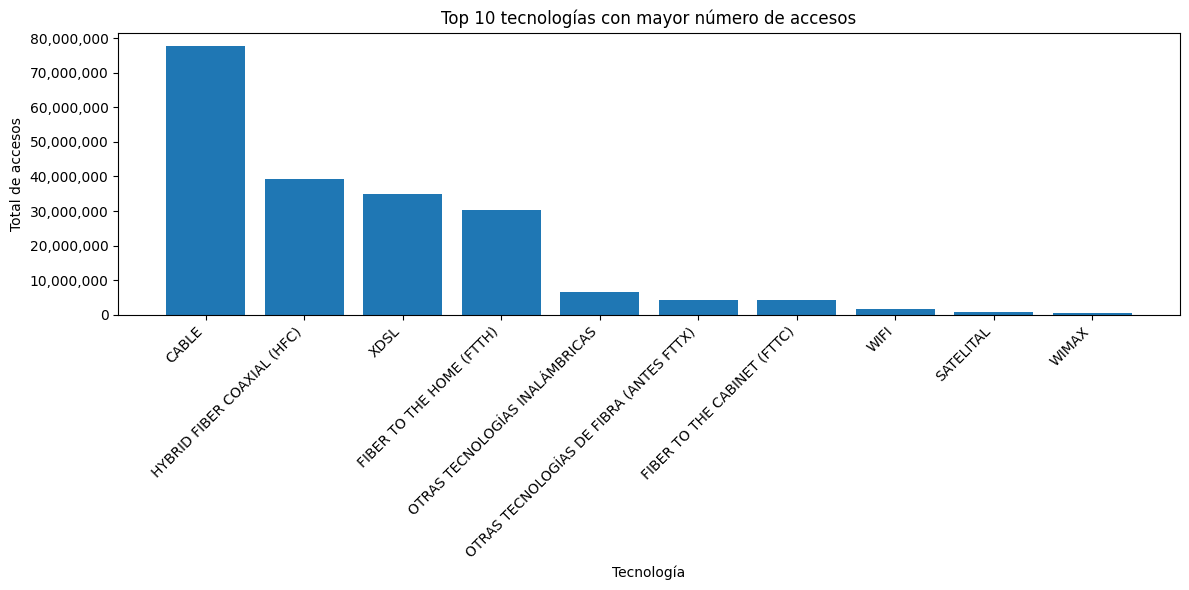

In [43]:
internet_tecnologia_pd = (
    internet.groupBy("TECNOLOGIA")
    .agg(F.sum("No DE ACCESOS").alias("total_accesos"))
    .orderBy(F.desc("total_accesos"))
    .limit(10)
    .toPandas()
)

# Guardar tabla
internet_tecnologia_pd.to_csv(
    "outputs_eda/tables/internet_tecnologia_top10.csv",
    index=False
)

# Graficar
plt.figure(figsize=(12,6))
plt.bar(internet_tecnologia_pd["TECNOLOGIA"], internet_tecnologia_pd["total_accesos"])

ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.xticks(rotation=45, ha="right")
plt.title("Top 10 tecnologías con mayor número de accesos")
plt.xlabel("Tecnología")
plt.ylabel("Total de accesos")
plt.tight_layout()
plt.savefig("outputs_eda/plots/g4_composicion_tecnologica_top10.png", dpi=300)
plt.show()
plt.close()

In [44]:
# Resumen por municipio y periodo
internet_municipios = internet.groupBy(
    "AÑO",
    "TRIMESTRE",
    "COD_MUNICIPIO"
).agg(
    F.sum("No DE ACCESOS").alias("TOTAL_ACCESOS"),

    # Segmento
    F.sum("ACCESOS_RESIDENCIAL").alias("TOTAL_ACCESOS_RESIDENCIAL"),
    F.sum("ACCESOS_CORPORATIVO").alias("TOTAL_ACCESOS_CORPORATIVO"),
    F.sum("ACCESOS_SIN_ESTRATIFICAR").alias("TOTAL_ACCESOS_SIN_ESTRATIFICAR"),
    F.sum("ACCESOS_OPERADOR").alias("TOTAL_ACCESOS_OPERADOR"),

    # Tecnología
    F.sum("ACCESOS_FIBRA").alias("TOTAL_ACCESOS_FIBRA"),
    F.sum("ACCESOS_CABLE").alias("TOTAL_ACCESOS_CABLE"),
    F.sum("ACCESOS_XDSL").alias("TOTAL_ACCESOS_XDSL"),
    F.sum("ACCESOS_SATELITAL").alias("TOTAL_ACCESOS_SATELITAL"),
    F.sum("ACCESOS_INALAMBRICA").alias("TOTAL_ACCESOS_INALAMBRICA"),
    F.sum("ACCESOS_OTRAS_FIJAS").alias("TOTAL_ACCESOS_OTRAS_FIJAS"),

    # Estrato residencial ponderado
    F.sum("ESTRATO_X_ACCESOS").alias("SUM_ESTRATO_X_ACCESOS"),

    # Velocidades ponderadas
    F.sum("BAJADA_X_ACCESOS").alias("SUM_BAJADA_X_ACCESOS"),
    F.sum("SUBIDA_X_ACCESOS").alias("SUM_SUBIDA_X_ACCESOS")
)

# Métricas derivadas
internet_municipios = internet_municipios.withColumn(
    "ESTRATO_PROMEDIO_RESIDENCIAL",
    F.when(
        F.col("TOTAL_ACCESOS_RESIDENCIAL") > 0,
        F.col("SUM_ESTRATO_X_ACCESOS") / F.col("TOTAL_ACCESOS_RESIDENCIAL")
    )
).withColumn(
    "VEL_BAJADA_PROMEDIO",
    F.when(
        F.col("TOTAL_ACCESOS") > 0,
        F.col("SUM_BAJADA_X_ACCESOS") / F.col("TOTAL_ACCESOS")
    )
).withColumn(
    "VEL_SUBIDA_PROMEDIO",
    F.when(
        F.col("TOTAL_ACCESOS") > 0,
        F.col("SUM_SUBIDA_X_ACCESOS") / F.col("TOTAL_ACCESOS")
    )
).withColumn(
    "PROP_RESIDENCIAL",
    F.col("TOTAL_ACCESOS_RESIDENCIAL") / F.col("TOTAL_ACCESOS")
).withColumn(
    "PROP_CORPORATIVO",
    F.col("TOTAL_ACCESOS_CORPORATIVO") / F.col("TOTAL_ACCESOS")
).withColumn(
    "PROP_SIN_ESTRATIFICAR",
    F.col("TOTAL_ACCESOS_SIN_ESTRATIFICAR") / F.col("TOTAL_ACCESOS")
).withColumn(
    "PROP_OPERADOR",
    F.col("TOTAL_ACCESOS_OPERADOR") / F.col("TOTAL_ACCESOS")
).withColumn(
    "PROP_FIBRA",
    F.col("TOTAL_ACCESOS_FIBRA") / F.col("TOTAL_ACCESOS")
).withColumn(
    "PROP_CABLE",
    F.col("TOTAL_ACCESOS_CABLE") / F.col("TOTAL_ACCESOS")
).withColumn(
    "PROP_XDSL",
    F.col("TOTAL_ACCESOS_XDSL") / F.col("TOTAL_ACCESOS")
).withColumn(
    "PROP_SATELITAL",
    F.col("TOTAL_ACCESOS_SATELITAL") / F.col("TOTAL_ACCESOS")
).withColumn(
    "PROP_INALAMBRICA",
    F.col("TOTAL_ACCESOS_INALAMBRICA") / F.col("TOTAL_ACCESOS")
).withColumn(
    "PROP_OTRAS_FIJAS",
    F.col("TOTAL_ACCESOS_OTRAS_FIJAS") / F.col("TOTAL_ACCESOS")
).drop(
    "SUM_ESTRATO_X_ACCESOS",
    "SUM_BAJADA_X_ACCESOS",
    "SUM_SUBIDA_X_ACCESOS"
)

In [45]:
internet_municipios.show(5, truncate=False)

+----+---------+-------------+-------------+-------------------------+-------------------------+------------------------------+----------------------+-------------------+-------------------+------------------+-----------------------+-------------------------+-------------------------+----------------------------+-------------------+-------------------+------------------+-------------------+---------------------+-------------+-------------------+-------------------+------------------+---------------------+--------------------+----------------+
|AÑO |TRIMESTRE|COD_MUNICIPIO|TOTAL_ACCESOS|TOTAL_ACCESOS_RESIDENCIAL|TOTAL_ACCESOS_CORPORATIVO|TOTAL_ACCESOS_SIN_ESTRATIFICAR|TOTAL_ACCESOS_OPERADOR|TOTAL_ACCESOS_FIBRA|TOTAL_ACCESOS_CABLE|TOTAL_ACCESOS_XDSL|TOTAL_ACCESOS_SATELITAL|TOTAL_ACCESOS_INALAMBRICA|TOTAL_ACCESOS_OTRAS_FIJAS|ESTRATO_PROMEDIO_RESIDENCIAL|VEL_BAJADA_PROMEDIO|VEL_SUBIDA_PROMEDIO|PROP_RESIDENCIAL  |PROP_CORPORATIVO   |PROP_SIN_ESTRATIFICAR|PROP_OPERADOR|PROP_FIBRA         |PR

In [46]:
internet_municipios.printSchema()

root
 |-- AÑO: integer (nullable = true)
 |-- TRIMESTRE: integer (nullable = true)
 |-- COD_MUNICIPIO: integer (nullable = true)
 |-- TOTAL_ACCESOS: long (nullable = true)
 |-- TOTAL_ACCESOS_RESIDENCIAL: long (nullable = true)
 |-- TOTAL_ACCESOS_CORPORATIVO: long (nullable = true)
 |-- TOTAL_ACCESOS_SIN_ESTRATIFICAR: long (nullable = true)
 |-- TOTAL_ACCESOS_OPERADOR: long (nullable = true)
 |-- TOTAL_ACCESOS_FIBRA: long (nullable = true)
 |-- TOTAL_ACCESOS_CABLE: long (nullable = true)
 |-- TOTAL_ACCESOS_XDSL: long (nullable = true)
 |-- TOTAL_ACCESOS_SATELITAL: long (nullable = true)
 |-- TOTAL_ACCESOS_INALAMBRICA: long (nullable = true)
 |-- TOTAL_ACCESOS_OTRAS_FIJAS: long (nullable = true)
 |-- ESTRATO_PROMEDIO_RESIDENCIAL: double (nullable = true)
 |-- VEL_BAJADA_PROMEDIO: double (nullable = true)
 |-- VEL_SUBIDA_PROMEDIO: double (nullable = true)
 |-- PROP_RESIDENCIAL: double (nullable = true)
 |-- PROP_CORPORATIVO: double (nullable = true)
 |-- PROP_SIN_ESTRATIFICAR: double (nul

In [47]:
internet_municipios.summary().show()

+-------+------------------+------------------+------------------+-----------------+-------------------------+-------------------------+------------------------------+----------------------+-------------------+-------------------+------------------+-----------------------+-------------------------+-------------------------+----------------------------+-------------------+-------------------+------------------+-------------------+---------------------+--------------------+--------------------+--------------------+-------------------+--------------------+--------------------+--------------------+
|summary|               AÑO|         TRIMESTRE|     COD_MUNICIPIO|    TOTAL_ACCESOS|TOTAL_ACCESOS_RESIDENCIAL|TOTAL_ACCESOS_CORPORATIVO|TOTAL_ACCESOS_SIN_ESTRATIFICAR|TOTAL_ACCESOS_OPERADOR|TOTAL_ACCESOS_FIBRA|TOTAL_ACCESOS_CABLE|TOTAL_ACCESOS_XDSL|TOTAL_ACCESOS_SATELITAL|TOTAL_ACCESOS_INALAMBRICA|TOTAL_ACCESOS_OTRAS_FIJAS|ESTRATO_PROMEDIO_RESIDENCIAL|VEL_BAJADA_PROMEDIO|VEL_SUBIDA_PROMEDIO|  PR

In [48]:
segmento_anual = (
    internet_municipios
    .groupBy("AÑO")
    .agg(
        F.sum("TOTAL_ACCESOS_RESIDENCIAL").alias("residencial"),
        F.sum("TOTAL_ACCESOS_CORPORATIVO").alias("corporativo")
    )
    .orderBy("AÑO")
    .toPandas()
)

plt.figure(figsize=(10,6))
plt.plot(segmento_anual["AÑO"], segmento_anual["residencial"], marker="o", label="Residencial")
plt.plot(segmento_anual["AÑO"], segmento_anual["corporativo"], marker="o", label="Corporativo")
plt.title("Evolución de accesos residenciales y corporativos")
plt.xlabel("Año")
plt.ylabel("Número de accesos")
plt.legend()
plt.tight_layout()
plt.savefig("outputs_eda/plots/g8_residencial_vs_corporativo.png", dpi=300)
plt.close()

In [49]:
icfes=icfes.withColumn("PERIODO", F.col("PERIODO").cast("string"))
icfes=icfes.withColumn("AÑO", F.substring(F.col("PERIODO"), 1, 4))
icfes=icfes.withColumn("TRIMESTRE", F.substring(F.col("PERIODO"), 5, 1))
icfes.select("PERIODO","AÑO","TRIMESTRE").show(5)

+-------+----+---------+
|PERIODO| AÑO|TRIMESTRE|
+-------+----+---------+
|  20131|2013|        1|
|  20194|2019|        4|
|  20194|2019|        4|
|  20122|2012|        2|
|  20132|2013|        2|
+-------+----+---------+
only showing top 5 rows


In [50]:
icfes_anio_counts = (
    icfes.groupBy("AÑO")
    .count()
    .orderBy("AÑO")
    .toPandas()
)
icfes_anio_counts.to_csv("outputs_eda/tables/icfes_anio_counts.csv", index=False)

In [51]:
icfes_genero = (
    icfes.groupBy("ESTU_GENERO")
    .count()
    .orderBy(F.desc("count"))
    .toPandas()
)
icfes_genero.to_csv("outputs_eda/tables/icfes_genero.csv", index=False)

In [52]:
icfes= icfes.dropna(subset=['PUNT_INGLES','PUNT_MATEMATICAS','PUNT_SOCIALES_CIUDADANAS','PUNT_C_NATURALES','PUNT_LECTURA_CRITICA'])

In [53]:
icfes.describe().show()

+-------+------------------+------------------+------------------+-------------------+-------------+---------------+-----------------+-----------------------------+--------------------+------------------------+------------------------+------------------+--------------------+-----------+------------+--------------------+---------------+---------------------------+--------------------+-------------------+---------------------------+---------------------------+---------------------+---------------------+-----------------------+-----------------+------------------------+---------------+--------------------+-----------+-----------------------+-----------------+-----------------+----------------+---------------------+-----------------+--------------------+--------------------+--------------------+------------------+-------------------+--------------------+------------------+------------------+-------------+------------------+------------------+------------------------+------------------+----

In [54]:
icfes=icfes.select("PERIODO","AÑO","TRIMESTRE","COLE_COD_MCPIO_UBICACION","ESTU_FECHANACIMIENTO","ESTU_GENERO","FAMI_ESTRATOVIVIENDA","FAMI_TIENECOMPUTADOR","FAMI_TIENEINTERNET",'PUNT_INGLES','PUNT_MATEMATICAS','PUNT_SOCIALES_CIUDADANAS','PUNT_C_NATURALES','PUNT_LECTURA_CRITICA',"PUNT_GLOBAL")

In [55]:
icfes.describe().show()

+-------+------------------+------------------+------------------+------------------------+--------------------+-----------+--------------------+--------------------+------------------+------------------+------------------+------------------------+------------------+--------------------+-----------------+
|summary|           PERIODO|               AÑO|         TRIMESTRE|COLE_COD_MCPIO_UBICACION|ESTU_FECHANACIMIENTO|ESTU_GENERO|FAMI_ESTRATOVIVIENDA|FAMI_TIENECOMPUTADOR|FAMI_TIENEINTERNET|       PUNT_INGLES|  PUNT_MATEMATICAS|PUNT_SOCIALES_CIUDADANAS|  PUNT_C_NATURALES|PUNT_LECTURA_CRITICA|      PUNT_GLOBAL|
+-------+------------------+------------------+------------------+------------------------+--------------------+-----------+--------------------+--------------------+------------------+------------------+------------------+------------------------+------------------+--------------------+-----------------+
|  count|           4496002|           4496002|           4496002|             

In [56]:
icfes.show(5)

+-------+----+---------+------------------------+--------------------+-----------+--------------------+--------------------+------------------+-----------+----------------+------------------------+----------------+--------------------+-----------+
|PERIODO| AÑO|TRIMESTRE|COLE_COD_MCPIO_UBICACION|ESTU_FECHANACIMIENTO|ESTU_GENERO|FAMI_ESTRATOVIVIENDA|FAMI_TIENECOMPUTADOR|FAMI_TIENEINTERNET|PUNT_INGLES|PUNT_MATEMATICAS|PUNT_SOCIALES_CIUDADANAS|PUNT_C_NATURALES|PUNT_LECTURA_CRITICA|PUNT_GLOBAL|
+-------+----+---------+------------------------+--------------------+-----------+--------------------+--------------------+------------------+-----------+----------------+------------------------+----------------+--------------------+-----------+
|  20194|2019|        4|                   41016|          15/02/2003|          F|           Estrato 2|                  Si|                Si|         71|              66|                      70|              65|                  69|        339|
|  20194

In [57]:
icfes.select("FAMI_ESTRATOVIVIENDA").distinct().show()

+--------------------+
|FAMI_ESTRATOVIVIENDA|
+--------------------+
|           Estrato 3|
|           Estrato 2|
|           Estrato 6|
|           Estrato 4|
|         Sin Estrato|
|           Estrato 1|
|           Estrato 5|
|                NULL|
+--------------------+



In [58]:
icfes= icfes.withColumn("ESTU_FECHANACIMIENTO", F.to_date(F.col("ESTU_FECHANACIMIENTO"),"dd/MM/yyyy"))
icfes = icfes.withColumn("EDAD",F.floor(F.months_between(F.current_date(), F.col("ESTU_FECHANACIMIENTO")) / 12))
icfes= icfes.withColumn("SEXO", F.when(F.col("ESTU_GENERO")=="M",1).when(F.col("ESTU_GENERO")=="F",0).otherwise(None))
icfes = icfes.withColumn("FAMI_ESTRATOVIVIENDA",F.when(F.col("FAMI_ESTRATOVIVIENDA") == "Estrato 1", 1)
     .when(F.col("FAMI_ESTRATOVIVIENDA") == "Estrato 2", 2)
     .when(F.col("FAMI_ESTRATOVIVIENDA") == "Estrato 3", 3)
     .when(F.col("FAMI_ESTRATOVIVIENDA") == "Estrato 4", 4)
     .when(F.col("FAMI_ESTRATOVIVIENDA") == "Estrato 5", 5)
     .when(F.col("FAMI_ESTRATOVIVIENDA") == "Estrato 6", 6)
     .when(F.col("FAMI_ESTRATOVIVIENDA") == "Sin Estrato", 0)
     .otherwise(None)
     .cast("int")
)
icfes = icfes.withColumn("FAMI_TIENECOMPUTADOR", F.when(F.col("FAMI_TIENECOMPUTADOR") == "Si", 1).when(F.col("FAMI_TIENECOMPUTADOR") == "No", 0).otherwise(None))
icfes = icfes.withColumn("FAMI_TIENEINTERNET", F.when(F.col("FAMI_TIENEINTERNET") == "Si", 1).when(F.col("FAMI_TIENEINTERNET") == "No", 0).otherwise(None))
icfes = icfes.withColumn("COLE_COD_MCPIO_UBICACION", F.col("COLE_COD_MCPIO_UBICACION").cast("int"))
icfes.show(5)

+-------+----+---------+------------------------+--------------------+-----------+--------------------+--------------------+------------------+-----------+----------------+------------------------+----------------+--------------------+-----------+----+----+
|PERIODO| AÑO|TRIMESTRE|COLE_COD_MCPIO_UBICACION|ESTU_FECHANACIMIENTO|ESTU_GENERO|FAMI_ESTRATOVIVIENDA|FAMI_TIENECOMPUTADOR|FAMI_TIENEINTERNET|PUNT_INGLES|PUNT_MATEMATICAS|PUNT_SOCIALES_CIUDADANAS|PUNT_C_NATURALES|PUNT_LECTURA_CRITICA|PUNT_GLOBAL|EDAD|SEXO|
+-------+----+---------+------------------------+--------------------+-----------+--------------------+--------------------+------------------+-----------+----------------+------------------------+----------------+--------------------+-----------+----+----+
|  20194|2019|        4|                   41016|          2003-02-15|          F|                   2|                   1|                 1|         71|              66|                      70|              65|            

In [59]:
icfes.groupBy("FAMI_ESTRATOVIVIENDA").count().show()

+--------------------+-------+
|FAMI_ESTRATOVIVIENDA|  count|
+--------------------+-------+
|                NULL| 178584|
|                   1|1520472|
|                   6|  48261|
|                   3| 851055|
|                   5|  80877|
|                   4| 213549|
|                   2|1514679|
|                   0|  88525|
+--------------------+-------+



In [60]:
icfes.filter(F.col("COLE_COD_MCPIO_UBICACION").isNull()).count()

2

In [61]:
icfes= icfes.dropna(subset=["COLE_COD_MCPIO_UBICACION"])

In [62]:
icfes = icfes.select("AÑO","TRIMESTRE","COLE_COD_MCPIO_UBICACION","EDAD","FAMI_ESTRATOVIVIENDA","FAMI_TIENECOMPUTADOR","FAMI_TIENEINTERNET",'PUNT_INGLES','PUNT_MATEMATICAS','PUNT_SOCIALES_CIUDADANAS','PUNT_C_NATURALES','PUNT_LECTURA_CRITICA',"SEXO","PUNT_GLOBAL")

In [63]:
icfes.show(5)

+----+---------+------------------------+----+--------------------+--------------------+------------------+-----------+----------------+------------------------+----------------+--------------------+----+-----------+
| AÑO|TRIMESTRE|COLE_COD_MCPIO_UBICACION|EDAD|FAMI_ESTRATOVIVIENDA|FAMI_TIENECOMPUTADOR|FAMI_TIENEINTERNET|PUNT_INGLES|PUNT_MATEMATICAS|PUNT_SOCIALES_CIUDADANAS|PUNT_C_NATURALES|PUNT_LECTURA_CRITICA|SEXO|PUNT_GLOBAL|
+----+---------+------------------------+----+--------------------+--------------------+------------------+-----------+----------------+------------------------+----------------+--------------------+----+-----------+
|2019|        4|                   41016|  23|                   2|                   1|                 1|         71|              66|                      70|              65|                  69|   0|        339|
|2019|        4|                   41016|  23|                   2|                   1|                 1|         71|             

In [64]:
icfes.summary().show()

+-------+------------------+------------------+------------------------+-----------------+--------------------+--------------------+------------------+------------------+------------------+------------------------+------------------+--------------------+-------------------+------------------+
|summary|               AÑO|         TRIMESTRE|COLE_COD_MCPIO_UBICACION|             EDAD|FAMI_ESTRATOVIVIENDA|FAMI_TIENECOMPUTADOR|FAMI_TIENEINTERNET|       PUNT_INGLES|  PUNT_MATEMATICAS|PUNT_SOCIALES_CIUDADANAS|  PUNT_C_NATURALES|PUNT_LECTURA_CRITICA|               SEXO|       PUNT_GLOBAL|
+-------+------------------+------------------+------------------------+-----------------+--------------------+--------------------+------------------+------------------+------------------+------------------------+------------------+--------------------+-------------------+------------------+
|  count|           4496000|           4496000|                 4496000|          4495835|             4317418|       

In [65]:
icfes.groupby("EDAD").count().orderBy(F.col("EDAD").asc()).show(100)

+----+------+
|EDAD| count|
+----+------+
|NULL|   165|
| -74|     1|
| -73|     4|
| -72|     3|
| -71|     2|
| -70|     2|
| -69|     1|
| -29|     2|
|   3|     4|
|   4|    80|
|   5|     9|
|   6|     9|
|   7|   241|
|   8|    46|
|   9|   156|
|  10|   192|
|  11|   138|
|  12|  1905|
|  13|   247|
|  14|   222|
|  15|   296|
|  16|   504|
|  17|   466|
|  18|  2158|
|  19| 72210|
|  20|500644|
|  21|289559|
|  22|217417|
|  23|520651|
|  24|364539|
|  25|452080|
|  26|499036|
|  27|513906|
|  28|470148|
|  29|255770|
|  30|116142|
|  31| 48614|
|  32| 24185|
|  33| 15542|
|  34| 11661|
|  35|  9690|
|  36|  8627|
|  37|  7616|
|  38|  6950|
|  39|  6381|
|  40|  5882|
|  41|  5644|
|  42|  5135|
|  43|  4952|
|  44|  4526|
|  45|  4192|
|  46|  3998|
|  47|  3570|
|  48|  3232|
|  49|  2943|
|  50|  2652|
|  51|  2493|
|  52|  2203|
|  53|  2053|
|  54|  1892|
|  55|  1881|
|  56|  1711|
|  57|  1525|
|  58|  1366|
|  59|  1324|
|  60|  1162|
|  61|  1080|
|  62|   961|
|  63|

In [66]:
icfes = icfes.withColumn(
    "EDAD",
    F.when((F.col("EDAD") >= 12) & (F.col("EDAD") <= 35), F.col("EDAD"))
     .otherwise(None)
)

In [67]:
icfes_municipios = icfes.groupBy(
    "AÑO",
    "TRIMESTRE",
    "COLE_COD_MCPIO_UBICACION"
).agg(
    F.count("*").alias("TOTAL_ESTUDIANTES"),
    F.avg("EDAD").alias("EDAD_PROMEDIO"),
    F.avg("FAMI_ESTRATOVIVIENDA").alias("ESTRATO_PROMEDIO"),
    F.avg("FAMI_TIENECOMPUTADOR").alias("PROP_COMPUTADOR"),
    F.avg("FAMI_TIENEINTERNET").alias("PROP_INTERNET_HOGAR"),
    F.avg("SEXO").alias("PROP_HOMBRES"),
    F.avg("PUNT_INGLES").alias("PROM_PUNT_INGLES"),
    F.avg("PUNT_MATEMATICAS").alias("PROM_PUNT_MATEMATICAS"),
    F.avg("PUNT_SOCIALES_CIUDADANAS").alias("PROM_PUNT_SOCIALES"),
    F.avg("PUNT_C_NATURALES").alias("PROM_PUNT_NATURALES"),
    F.avg("PUNT_LECTURA_CRITICA").alias("PROM_PUNT_LECTURA"),
    F.avg("PUNT_GLOBAL").alias("PROM_PUNT_GLOBAL")
).withColumnRenamed(
    "COLE_COD_MCPIO_UBICACION",
    "COD_MUNICIPIO"
)

In [68]:
icfes_municipios.show(5, truncate=False)

+----+---------+-------------+-----------------+------------------+------------------+-------------------+-------------------+-------------------+-----------------+---------------------+------------------+-------------------+------------------+------------------+
|AÑO |TRIMESTRE|COD_MUNICIPIO|TOTAL_ESTUDIANTES|EDAD_PROMEDIO     |ESTRATO_PROMEDIO  |PROP_COMPUTADOR    |PROP_INTERNET_HOGAR|PROP_HOMBRES       |PROM_PUNT_INGLES |PROM_PUNT_MATEMATICAS|PROM_PUNT_SOCIALES|PROM_PUNT_NATURALES|PROM_PUNT_LECTURA |PROM_PUNT_GLOBAL  |
+----+---------+-------------+-----------------+------------------+------------------+-------------------+-------------------+-------------------+-----------------+---------------------+------------------+-------------------+------------------+------------------+
|2019|4        |76001        |36012            |23.925450016981774|2.139711696368834 |0.6836997193638915 |0.8175054439874183 |0.43387947792279924|48.9254137509719 |49.6207375319338     |46.37020993002333 |48.

In [69]:
icfes_municipios.summary().show()

+-------+------------------+------------------+-----------------+------------------+------------------+------------------+-------------------+-------------------+-------------------+------------------+---------------------+------------------+-------------------+-----------------+------------------+
|summary|               AÑO|         TRIMESTRE|    COD_MUNICIPIO| TOTAL_ESTUDIANTES|     EDAD_PROMEDIO|  ESTRATO_PROMEDIO|    PROP_COMPUTADOR|PROP_INTERNET_HOGAR|       PROP_HOMBRES|  PROM_PUNT_INGLES|PROM_PUNT_MATEMATICAS|PROM_PUNT_SOCIALES|PROM_PUNT_NATURALES|PROM_PUNT_LECTURA|  PROM_PUNT_GLOBAL|
+-------+------------------+------------------+-----------------+------------------+------------------+------------------+-------------------+-------------------+-------------------+------------------+---------------------+------------------+-------------------+-----------------+------------------+
|  count|              7427|              7427|             7427|              7427|              74

In [70]:
df_final = icfes_municipios.join(
    internet_municipios,
    on=["AÑO", "TRIMESTRE", "COD_MUNICIPIO"],
    how="inner"
)

In [71]:
df_final.show(5, truncate=False)

+----+---------+-------------+-----------------+------------------+------------------+-------------------+-------------------+-------------------+------------------+---------------------+------------------+-------------------+------------------+------------------+-------------+-------------------------+-------------------------+------------------------------+----------------------+-------------------+-------------------+------------------+-----------------------+-------------------------+-------------------------+----------------------------+-------------------+-------------------+------------------+-------------------+---------------------+-------------------+---------------------+--------------------+-------------------+---------------------+---------------------+---------------------+
|AÑO |TRIMESTRE|COD_MUNICIPIO|TOTAL_ESTUDIANTES|EDAD_PROMEDIO     |ESTRATO_PROMEDIO  |PROP_COMPUTADOR    |PROP_INTERNET_HOGAR|PROP_HOMBRES       |PROM_PUNT_INGLES  |PROM_PUNT_MATEMATICAS|PROM_PUNT_SOCI

In [72]:
df_final.summary().show()

+-------+------------------+------------------+------------------+-----------------+------------------+------------------+-------------------+-------------------+-------------------+------------------+---------------------+------------------+-------------------+------------------+------------------+------------------+-------------------------+-------------------------+------------------------------+----------------------+-------------------+-------------------+------------------+-----------------------+-------------------------+-------------------------+----------------------------+-------------------+-------------------+------------------+-------------------+---------------------+--------------------+-------------------+-------------------+-------------------+--------------------+--------------------+--------------------+
|summary|               AÑO|         TRIMESTRE|     COD_MUNICIPIO|TOTAL_ESTUDIANTES|     EDAD_PROMEDIO|  ESTRATO_PROMEDIO|    PROP_COMPUTADOR|PROP_INTERNET_HOGAR|   

In [73]:
df_final.filter(F.col("ESTRATO_PROMEDIO").isNull()).show(5, truncate=False)

+----+---------+-------------+-----------------+-------------+----------------+---------------+-------------------+------------+----------------+---------------------+------------------+-------------------+-----------------+----------------+-------------+-------------------------+-------------------------+------------------------------+----------------------+-------------------+-------------------+------------------+-----------------------+-------------------------+-------------------------+----------------------------+-------------------+-------------------+-------------------+-------------------+---------------------+-------------+--------------------+------------------+-------------------+--------------------+--------------------+----------------+
|AÑO |TRIMESTRE|COD_MUNICIPIO|TOTAL_ESTUDIANTES|EDAD_PROMEDIO|ESTRATO_PROMEDIO|PROP_COMPUTADOR|PROP_INTERNET_HOGAR|PROP_HOMBRES|PROM_PUNT_INGLES|PROM_PUNT_MATEMATICAS|PROM_PUNT_SOCIALES|PROM_PUNT_NATURALES|PROM_PUNT_LECTURA|PROM_PUNT_GLOBA

In [74]:
top_puntaje = (
    df_final
    .select("COD_MUNICIPIO", "PROM_PUNT_GLOBAL")
    .orderBy(F.desc("PROM_PUNT_GLOBAL"))
    .limit(20)
    .toPandas()
)
top_puntaje.to_csv("outputs_eda/tables/top_puntaje_global.csv", index=False)

bottom_puntaje = (
    df_final
    .select("COD_MUNICIPIO", "PROM_PUNT_GLOBAL")
    .orderBy("PROM_PUNT_GLOBAL")
    .limit(20)
    .toPandas()
)
bottom_puntaje.to_csv("outputs_eda/tables/bottom_puntaje_global.csv", index=False)

In [75]:
top_velocidad = (
    df_final
    .select("COD_MUNICIPIO", "VEL_BAJADA_PROMEDIO")
    .orderBy(F.desc("VEL_BAJADA_PROMEDIO"))
    .limit(20)
    .toPandas()
)
top_velocidad.to_csv("outputs_eda/tables/top_velocidad.csv", index=False)

bottom_velocidad = (
    df_final
    .select("COD_MUNICIPIO", "VEL_BAJADA_PROMEDIO")
    .orderBy("VEL_BAJADA_PROMEDIO")
    .limit(20)
    .toPandas()
)
bottom_velocidad.to_csv("outputs_eda/tables/bottom_velocidad.csv", index=False)

In [76]:
pdf = (
    df_final
    .select("PROM_PUNT_GLOBAL")
    .dropna()
    .toPandas()
)

plt.figure(figsize=(10,6))
plt.hist(pdf["PROM_PUNT_GLOBAL"], bins=30)
plt.title("Distribución del puntaje global promedio municipal")
plt.xlabel("Puntaje global promedio")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.savefig("outputs_eda/plots/g2_puntaje_global_distribucion.png", dpi=300)
plt.close()

In [77]:
pdf = (
    df_final
    .select("VEL_BAJADA_PROMEDIO", "PROM_PUNT_GLOBAL")
    .dropna()
    .toPandas()
)

plt.figure(figsize=(8,6))
plt.scatter(pdf["VEL_BAJADA_PROMEDIO"], pdf["PROM_PUNT_GLOBAL"], alpha=0.4)
plt.title("Velocidad promedio de bajada vs puntaje global promedio")
plt.xlabel("Velocidad promedio de bajada")
plt.ylabel("Puntaje global promedio")
plt.tight_layout()
plt.savefig("outputs_eda/plots/g5_scatter_velocidad_vs_puntaje.png", dpi=300)
plt.close()

In [78]:
pdf = (
    df_final
    .select("PROP_INTERNET_HOGAR", "PROM_PUNT_GLOBAL")
    .dropna()
    .toPandas()
)

plt.figure(figsize=(8,6))
plt.scatter(pdf["PROP_INTERNET_HOGAR"], pdf["PROM_PUNT_GLOBAL"], alpha=0.4)
plt.title("Proporción de internet en el hogar vs puntaje global promedio")
plt.xlabel("Proporción de estudiantes con internet en el hogar")
plt.ylabel("Puntaje global promedio")
plt.tight_layout()
plt.savefig("outputs_eda/plots/g6_scatter_internet_hogar_vs_puntaje.png", dpi=300)
plt.close()

---
## Entrega 2


## 1. Filtros y Transformaciones Finales

In [79]:
import os
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import RegressionEvaluator, ClusteringEvaluator
from pyspark.ml import Pipeline
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
import numpy as np

os.makedirs("outputs_e2", exist_ok=True)
os.makedirs("outputs_e2/plots", exist_ok=True)
os.makedirs("outputs_e2/tables", exist_ok=True)

print("Librerías importadas correctamente.")
print(f"Registros en df_final: {df_final.count()}")

Librerías importadas correctamente.
Registros en df_final: 3904


In [80]:
# Filtro 1: Eliminar registros del año 2016 (solo 463 accesos en todo el año, dato atípico estructural)
n_antes = df_final.count()
df_final = df_final.filter(F.col("AÑO") >= 2017)
n_despues = df_final.count()
print(f"Filtro 1 - Eliminación año 2016: {n_antes} → {n_despues} registros ({n_antes - n_despues} eliminados)")

Filtro 1 - Eliminación año 2016: 3904 → 3899 registros (5 eliminados)


In [81]:
df_final.groupBy("AÑO").count().orderBy("AÑO").show()

+----+-----+
| AÑO|count|
+----+-----+
|2017| 1140|
|2018|  134|
|2019| 1148|
|2020|  103|
|2021|  101|
|2022| 1273|
+----+-----+



In [82]:
# Filtro 2: Eliminar outliers extremos en velocidad de bajada (percentil 95)
# En la exploración se observaron valores > 100.000 Mbps que son errores de reporte
p95 = df_final.approxQuantile("VEL_BAJADA_PROMEDIO", [0.95], 0.01)[0]
print(f"Percentil 95 de VEL_BAJADA_PROMEDIO: {p95:.2f}")

n_antes = df_final.count()
df_final = df_final.filter(F.col("VEL_BAJADA_PROMEDIO") <= p95)
n_despues = df_final.count()
print(f"Filtro 2 - Outliers velocidad: {n_antes} → {n_despues} registros ({n_antes - n_despues} eliminados)")

Percentil 95 de VEL_BAJADA_PROMEDIO: 104.90
Filtro 2 - Outliers velocidad: 3899 → 3668 registros (231 eliminados)


In [83]:
df_final.select("VEL_BAJADA_PROMEDIO").describe().show()

+-------+-------------------+
|summary|VEL_BAJADA_PROMEDIO|
+-------+-------------------+
|  count|               3668|
|   mean|  14.29780333909279|
| stddev|  17.10216065261998|
|    min|               0.02|
|    max| 104.89880364340678|
+-------+-------------------+



In [84]:
# Transformación 1: Log de accesos totales (distribución muy sesgada a la derecha)
df_final = df_final.withColumn(
    "LOG_TOTAL_ACCESOS",
    F.log1p(F.col("TOTAL_ACCESOS"))
)

# Transformación 2: Log de accesos residenciales
df_final = df_final.withColumn(
    "LOG_ACCESOS_RESIDENCIAL",
    F.log1p(F.col("TOTAL_ACCESOS_RESIDENCIAL"))
)

# Variables auxiliares normalizadas para construir el índice en una escala comparable
stats_indice = df_final.agg(
    F.min("LOG_TOTAL_ACCESOS").alias("min_log_total"),
    F.max("LOG_TOTAL_ACCESOS").alias("max_log_total"),
    F.min("VEL_BAJADA_PROMEDIO").alias("min_vel_bajada"),
    F.max("VEL_BAJADA_PROMEDIO").alias("max_vel_bajada"),
    F.min("PROP_FIBRA").alias("min_prop_fibra"),
    F.max("PROP_FIBRA").alias("max_prop_fibra")
).collect()[0]

df_final = df_final.withColumn(
    "LOG_TOTAL_ACCESOS_NORM",
    F.when(
        F.lit(stats_indice["max_log_total"] - stats_indice["min_log_total"]) != 0,
        (F.col("LOG_TOTAL_ACCESOS") - F.lit(stats_indice["min_log_total"])) /
        F.lit(stats_indice["max_log_total"] - stats_indice["min_log_total"])
    ).otherwise(F.lit(0.0))
)

df_final = df_final.withColumn(
    "VEL_BAJADA_PROMEDIO_NORM",
    F.when(
        F.lit(stats_indice["max_vel_bajada"] - stats_indice["min_vel_bajada"]) != 0,
        (F.col("VEL_BAJADA_PROMEDIO") - F.lit(stats_indice["min_vel_bajada"])) /
        F.lit(stats_indice["max_vel_bajada"] - stats_indice["min_vel_bajada"])
    ).otherwise(F.lit(0.0))
)

df_final = df_final.withColumn(
    "PROP_FIBRA_NORM",
    F.when(
        F.lit(stats_indice["max_prop_fibra"] - stats_indice["min_prop_fibra"]) != 0,
        (F.col("PROP_FIBRA") - F.lit(stats_indice["min_prop_fibra"])) /
        F.lit(stats_indice["max_prop_fibra"] - stats_indice["min_prop_fibra"])
    ).otherwise(F.lit(0.0))
)

# Transformación 3: Índice de conectividad compuesto
# Combina cantidad de accesos, velocidad y proporción de fibra en una escala comparable
df_final = df_final.withColumn(
    "INDICE_CONECTIVIDAD",
    (F.col("LOG_TOTAL_ACCESOS_NORM") * 0.4) +
    (F.col("VEL_BAJADA_PROMEDIO_NORM") * 0.3) +
    (F.col("PROP_FIBRA_NORM") * 0.3)
)

print("Transformaciones aplicadas correctamente.")

df_final.select(
    "LOG_TOTAL_ACCESOS",
    "LOG_ACCESOS_RESIDENCIAL",
    "LOG_TOTAL_ACCESOS_NORM",
    "VEL_BAJADA_PROMEDIO_NORM",
    "PROP_FIBRA_NORM",
    "INDICE_CONECTIVIDAD"
).describe().show()

Transformaciones aplicadas correctamente.
+-------+------------------+-----------------------+----------------------+------------------------+------------------+-------------------+
|summary| LOG_TOTAL_ACCESOS|LOG_ACCESOS_RESIDENCIAL|LOG_TOTAL_ACCESOS_NORM|VEL_BAJADA_PROMEDIO_NORM|   PROP_FIBRA_NORM|INDICE_CONECTIVIDAD|
+-------+------------------+-----------------------+----------------------+------------------------+------------------+-------------------+
|  count|              3668|                   3668|                  3668|                    3668|              3668|               3668|
|   mean| 5.987299935817878|      5.528147741073256|   0.38134496127376405|      0.1361362147840479|0.3705163526042071|0.30453375472598204|
| stddev| 2.432825476066505|     2.8683957207862125|   0.17523969931449554|     0.16306593952738238|0.3495884993619388|0.12039263187995836|
|    min|0.6931471805599453|                    0.0|                   0.0|                     0.0|               0.0

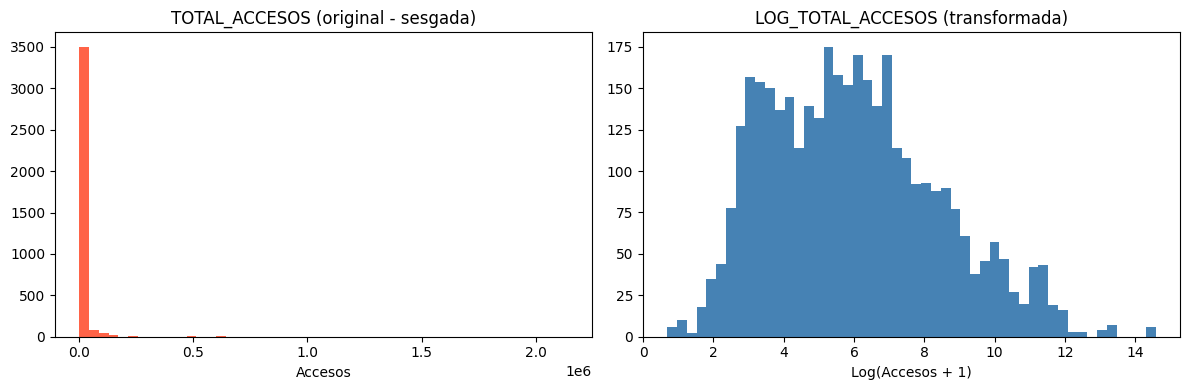

In [85]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Antes (variable original)
pdf = df_final.select("TOTAL_ACCESOS", "LOG_TOTAL_ACCESOS").dropna().toPandas()

axes[0].hist(pdf["TOTAL_ACCESOS"], bins=50, color="tomato")
axes[0].set_title("TOTAL_ACCESOS (original - sesgada)")
axes[0].set_xlabel("Accesos")

axes[1].hist(pdf["LOG_TOTAL_ACCESOS"], bins=50, color="steelblue")
axes[1].set_title("LOG_TOTAL_ACCESOS (transformada)")
axes[1].set_xlabel("Log(Accesos + 1)")

plt.tight_layout()
plt.show()

---
## 2. Respuesta a Preguntas de Negocio

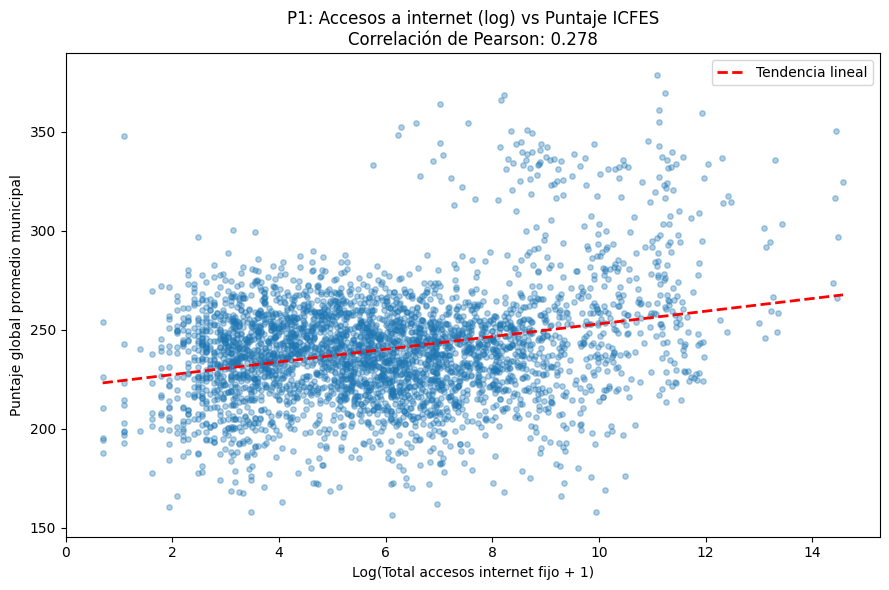

Correlación de Pearson: 0.2781


In [86]:
# Pregunta 1: ¿Cuál es la relación entre accesos a internet fijo y puntaje global promedio?
pdf = df_final.select("LOG_TOTAL_ACCESOS", "PROM_PUNT_GLOBAL").dropna().toPandas()

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(pdf["LOG_TOTAL_ACCESOS"], pdf["PROM_PUNT_GLOBAL"], alpha=0.35, s=15)
z = np.polyfit(pdf["LOG_TOTAL_ACCESOS"], pdf["PROM_PUNT_GLOBAL"], 1)
p = np.poly1d(z)
x_line = np.linspace(pdf["LOG_TOTAL_ACCESOS"].min(), pdf["LOG_TOTAL_ACCESOS"].max(), 200)
ax.plot(x_line, p(x_line), "r--", linewidth=2, label="Tendencia lineal")
corr = pdf["LOG_TOTAL_ACCESOS"].corr(pdf["PROM_PUNT_GLOBAL"])
ax.set_title(f"P1: Accesos a internet (log) vs Puntaje ICFES\nCorrelación de Pearson: {corr:.3f}")
ax.set_xlabel("Log(Total accesos internet fijo + 1)")
ax.set_ylabel("Puntaje global promedio municipal")
ax.legend()
plt.tight_layout()
plt.savefig("outputs_e2/plots/p1_accesos_vs_puntaje.png", dpi=150)
plt.show()
print(f"Correlación de Pearson: {corr:.4f}")

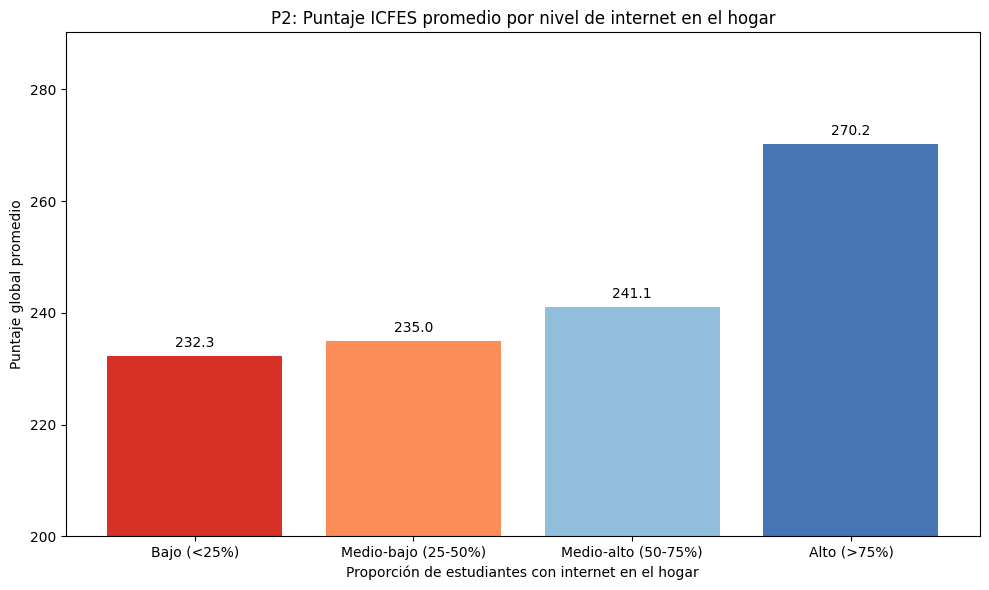

GRUPO_INTERNET_HOGAR  PUNTAJE_PROMEDIO  N_OBS
         Bajo (<25%)        232.318319   1123
 Medio-bajo (25-50%)        235.008678   1301
 Medio-alto (50-75%)        241.096246    763
         Alto (>75%)        270.209735    481


In [87]:
# Pregunta 2: ¿Municipios con mayor proporción de internet en el hogar tienen mejores resultados?
df_temp = df_final.withColumn(
    "GRUPO_INTERNET_HOGAR",
    F.when(F.col("PROP_INTERNET_HOGAR") < 0.25, "Bajo (<25%)")
     .when(F.col("PROP_INTERNET_HOGAR") < 0.50, "Medio-bajo (25-50%)")
     .when(F.col("PROP_INTERNET_HOGAR") < 0.75, "Medio-alto (50-75%)")
     .otherwise("Alto (>75%)")
)

res = df_temp.groupBy("GRUPO_INTERNET_HOGAR").agg(
    F.avg("PROM_PUNT_GLOBAL").alias("PUNTAJE_PROMEDIO"),
    F.avg("PROM_PUNT_MATEMATICAS").alias("PROM_MATEMATICAS"),
    F.avg("PROM_PUNT_INGLES").alias("PROM_INGLES"),
    F.avg("PROM_PUNT_LECTURA").alias("PROM_LECTURA"),
    F.count("*").alias("N_OBS")
).orderBy("PUNTAJE_PROMEDIO").toPandas()

orden = ["Bajo (<25%)", "Medio-bajo (25-50%)", "Medio-alto (50-75%)", "Alto (>75%)"]
res["GRUPO_INTERNET_HOGAR"] = pd.Categorical(res["GRUPO_INTERNET_HOGAR"], categories=orden, ordered=True)
res = res.sort_values("GRUPO_INTERNET_HOGAR")

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(res["GRUPO_INTERNET_HOGAR"], res["PUNTAJE_PROMEDIO"],
              color=["#d73027", "#fc8d59", "#91bfdb", "#4575b4"])
for bar, val in zip(bars, res["PUNTAJE_PROMEDIO"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{val:.1f}", ha="center", va="bottom", fontsize=10)
ax.set_title("P2: Puntaje ICFES promedio por nivel de internet en el hogar")
ax.set_xlabel("Proporción de estudiantes con internet en el hogar")
ax.set_ylabel("Puntaje global promedio")
ax.set_ylim(200, res["PUNTAJE_PROMEDIO"].max() + 20)
plt.tight_layout()
plt.savefig("outputs_e2/plots/p2_internet_hogar_vs_puntaje.png", dpi=150)
plt.show()
res.to_csv("outputs_e2/tables/p2_internet_hogar_grupos.csv", index=False)
print(res[["GRUPO_INTERNET_HOGAR", "PUNTAJE_PROMEDIO", "N_OBS"]].to_string(index=False))

In [88]:
# Pregunta 3: ¿Qué municipios tienen mayor brecha conectividad-desempeño?
# Alta conectividad + bajo rendimiento, o baja conectividad + alto rendimiento
from pyspark.ml.feature import MinMaxScaler

# Normalizar ambas variables entre 0 y 1 para comparar en la misma escala
stats = df_final.agg(
    F.min("LOG_TOTAL_ACCESOS").alias("min_acc"), F.max("LOG_TOTAL_ACCESOS").alias("max_acc"),
    F.min("PROM_PUNT_GLOBAL").alias("min_pun"), F.max("PROM_PUNT_GLOBAL").alias("max_pun")
).collect()[0]

df_brecha = df_final.withColumn(
    "ACC_NORM",
    (F.col("LOG_TOTAL_ACCESOS") - stats["min_acc"]) / (stats["max_acc"] - stats["min_acc"])
).withColumn(
    "PUN_NORM",
    (F.col("PROM_PUNT_GLOBAL") - stats["min_pun"]) / (stats["max_pun"] - stats["min_pun"])
).withColumn(
    "BRECHA", F.col("ACC_NORM") - F.col("PUN_NORM")
)

# Top 10 con alta conectividad y bajo rendimiento
alta_conn_bajo_rend = (
    df_brecha.orderBy(F.desc("BRECHA"))
    .select("COD_MUNICIPIO", "AÑO", "LOG_TOTAL_ACCESOS", "PROM_PUNT_GLOBAL", "BRECHA")
    .limit(10).toPandas()
)

# Top 10 con baja conectividad y alto rendimiento
baja_conn_alto_rend = (
    df_brecha.orderBy("BRECHA")
    .select("COD_MUNICIPIO", "AÑO", "LOG_TOTAL_ACCESOS", "PROM_PUNT_GLOBAL", "BRECHA")
    .limit(10).toPandas()
)

print("Top 10 municipios: alta conectividad, bajo rendimiento académico")
print(alta_conn_bajo_rend.to_string(index=False))
print("\nTop 10 municipios: baja conectividad, alto rendimiento académico")
print(baja_conn_alto_rend.to_string(index=False))

alta_conn_bajo_rend.to_csv("outputs_e2/tables/p3_alta_conn_bajo_rend.csv", index=False)
baja_conn_alto_rend.to_csv("outputs_e2/tables/p3_baja_conn_alto_rend.csv", index=False)

Top 10 municipios: alta conectividad, bajo rendimiento académico
 COD_MUNICIPIO  AÑO  LOG_TOTAL_ACCESOS  PROM_PUNT_GLOBAL   BRECHA
          5212 2021           9.946786        158.000000 0.659798
         18001 2020          10.109241        169.000000 0.621973
         25290 2021          10.480663        176.000000 0.617210
         81001 2021           9.293486        166.000000 0.576721
         27001 2022           9.843472        175.777778 0.572313
         17380 2021           9.340140        172.666667 0.550065
         73268 2021           9.602045        180.250000 0.534787
         70001 2018          10.448657        196.833333 0.521104
         50001 2020          11.531217        214.409091 0.519949
         70001 2022          10.684462        201.666667 0.516328

Top 10 municipios: baja conectividad, alto rendimiento académico
 COD_MUNICIPIO  AÑO  LOG_TOTAL_ACCESOS  PROM_PUNT_GLOBAL    BRECHA
         44035 2017           1.098612        347.833333 -0.832260
         

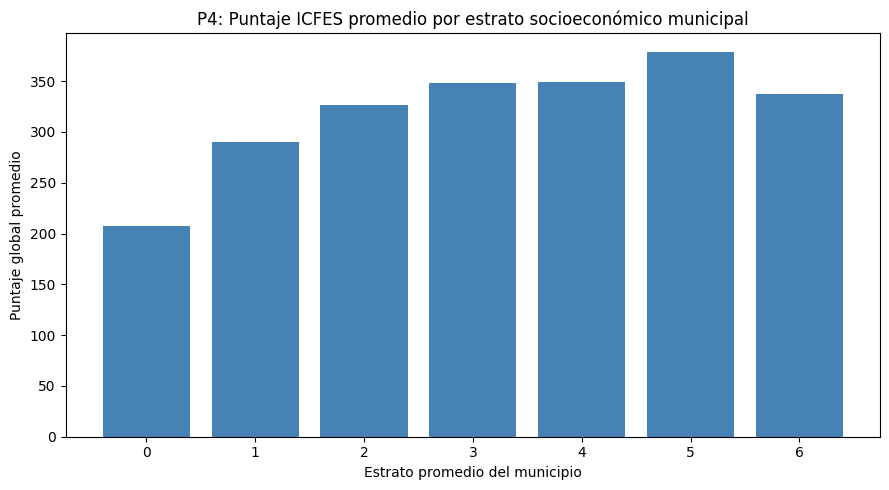

 ESTRATO_PROMEDIO  PUNTAJE_PROMEDIO  N_OBS ESTRATO_STR
         0.000000        180.500000      2           0
         0.333333        172.666667      1           0
         0.428571        207.857143      1           0
         0.500000        177.000000      1           0
         0.538462        195.062500      1           1
         0.600000        200.333333      1           1
         0.631579        202.052632      1           1
         0.666667        175.125000      2           1
         0.758621        192.689655      1           1
         0.761905        236.818182      1           1
         0.777778        215.333333      1           1
         0.800000        184.200000      1           1
         0.818182        177.454545      1           1
         0.823529        185.000000      1           1
         0.826087        210.565217      1           1
         0.833333        218.333333      1           1
         0.836066        211.633803      1           1
         0

In [89]:
# Pregunta 4: ¿Existe asociación entre estrato socioeconómico y puntaje ICFES?
res = df_final.groupBy("ESTRATO_PROMEDIO").agg(
    F.avg("PROM_PUNT_GLOBAL").alias("PUNTAJE_PROMEDIO"),
    F.count("*").alias("N_OBS")
).orderBy("ESTRATO_PROMEDIO").toPandas()

# Eliminar filas con NaN en estrato antes de graficar
res = res.dropna(subset=["ESTRATO_PROMEDIO"])
res["ESTRATO_STR"] = res["ESTRATO_PROMEDIO"].round(0).astype(int).astype(str)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(res["ESTRATO_STR"], res["PUNTAJE_PROMEDIO"], color="steelblue")
ax.set_title("P4: Puntaje ICFES promedio por estrato socioeconómico municipal")
ax.set_xlabel("Estrato promedio del municipio")
ax.set_ylabel("Puntaje global promedio")
plt.tight_layout()
plt.savefig("outputs_e2/plots/p4_estrato_vs_puntaje.png", dpi=150)
plt.show()
print(res.to_string(index=False))

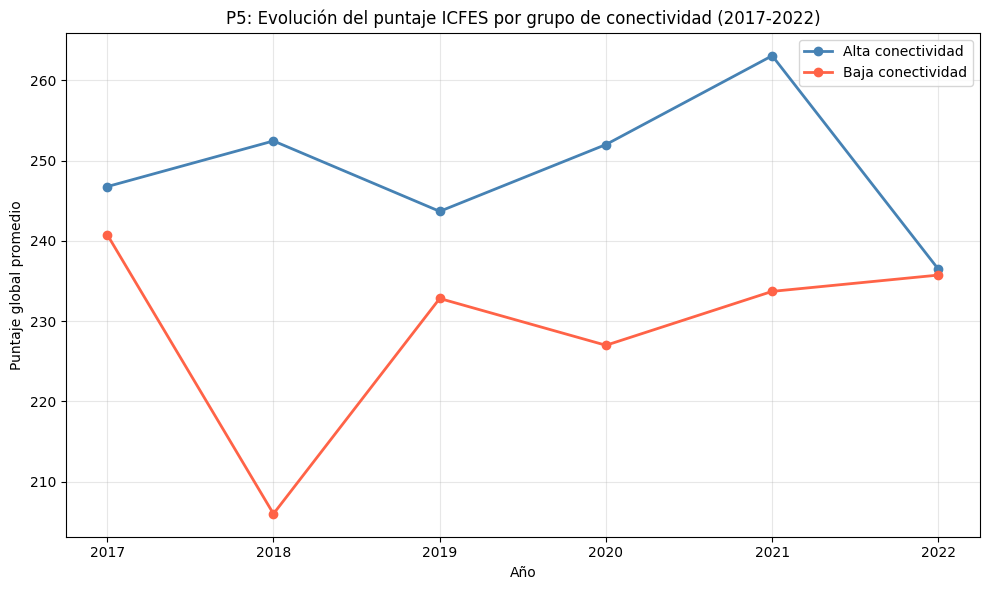

In [90]:
# Pregunta 5: ¿Cómo evolucionó la brecha ICFES entre municipios con mayor y menor acceso?
mediana_accesos = df_final.approxQuantile("TOTAL_ACCESOS", [0.5], 0.05)[0]

df_grupo = df_final.withColumn(
    "GRUPO_ACCESO",
    F.when(F.col("TOTAL_ACCESOS") >= mediana_accesos, "Alta conectividad")
     .otherwise("Baja conectividad")
)

evolucion = df_grupo.groupBy("AÑO", "GRUPO_ACCESO").agg(
    F.avg("PROM_PUNT_GLOBAL").alias("PUNTAJE_PROMEDIO")
).orderBy("AÑO", "GRUPO_ACCESO").toPandas()

fig, ax = plt.subplots(figsize=(10, 6))
for grupo, color in [("Alta conectividad", "steelblue"), ("Baja conectividad", "tomato")]:
    sub = evolucion[evolucion["GRUPO_ACCESO"] == grupo]
    ax.plot(sub["AÑO"], sub["PUNTAJE_PROMEDIO"], marker="o", label=grupo, color=color, linewidth=2)

ax.set_title("P5: Evolución del puntaje ICFES por grupo de conectividad (2017-2022)")
ax.set_xlabel("Año")
ax.set_ylabel("Puntaje global promedio")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("outputs_e2/plots/p5_evolucion_brecha.png", dpi=150)
plt.show()
evolucion.to_csv("outputs_e2/tables/p5_evolucion_brecha.csv", index=False)

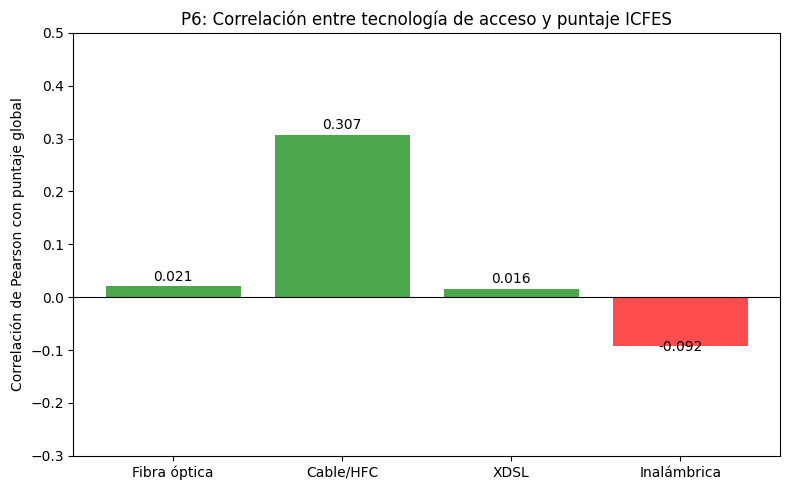

Fibra óptica: 0.0206
Cable/HFC: 0.3068
XDSL: 0.0156
Inalámbrica: -0.0919


In [91]:
# Pregunta 6: ¿Qué tecnología de acceso está más asociada a mejores resultados?
tecnologias = ["PROP_FIBRA", "PROP_CABLE", "PROP_XDSL", "PROP_INALAMBRICA"]
pdf = df_final.select(["PROM_PUNT_GLOBAL"] + tecnologias).dropna().toPandas()

correlaciones = {t: pdf[t].corr(pdf["PROM_PUNT_GLOBAL"]) for t in tecnologias}
nombres = ["Fibra óptica", "Cable/HFC", "XDSL", "Inalámbrica"]

fig, ax = plt.subplots(figsize=(8, 5))
colores = ["green" if v > 0 else "red" for v in correlaciones.values()]
bars = ax.bar(nombres, list(correlaciones.values()), color=colores, alpha=0.7)
ax.axhline(0, color="black", linewidth=0.8)
for bar, val in zip(bars, correlaciones.values()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (0.005 if val >= 0 else -0.015),
            f"{val:.3f}", ha="center", va="bottom", fontsize=10)
ax.set_title("P6: Correlación entre tecnología de acceso y puntaje ICFES")
ax.set_ylabel("Correlación de Pearson con puntaje global")
ax.set_ylim(-0.3, 0.5)
plt.tight_layout()
plt.savefig("outputs_e2/plots/p6_tecnologia_correlacion.png", dpi=150)
plt.show()
for nombre, (col, val) in zip(nombres, correlaciones.items()):
    print(f"{nombre}: {val:.4f}")

In [92]:
# Pregunta 7: ¿Cuáles municipios tienen simultáneamente menor ICFES y menor conectividad?
mediana_puntaje = df_final.approxQuantile("PROM_PUNT_GLOBAL", [0.25], 0.05)[0]
mediana_acc = df_final.approxQuantile("TOTAL_ACCESOS", [0.25], 0.05)[0]

municipios_criticos = (
    df_final
    .filter(
        (F.col("PROM_PUNT_GLOBAL") <= mediana_puntaje) &
        (F.col("TOTAL_ACCESOS") <= mediana_acc)
    )
    .groupBy("COD_MUNICIPIO")
    .agg(
        F.avg("PROM_PUNT_GLOBAL").alias("PUNTAJE_PROMEDIO"),
        F.avg("TOTAL_ACCESOS").alias("ACCESOS_PROMEDIO"),
        F.avg("ESTRATO_PROMEDIO").alias("ESTRATO_PROMEDIO"),
        F.count("*").alias("N_PERIODOS")
    )
    .orderBy("PUNTAJE_PROMEDIO")
    .limit(20)
    .toPandas()
)

print(f"Municipios en zona crítica (bajo ICFES + baja conectividad): {len(municipios_criticos)}")
print(municipios_criticos.to_string(index=False))
municipios_criticos.to_csv("outputs_e2/tables/p7_municipios_criticos.csv", index=False)

Municipios en zona crítica (bajo ICFES + baja conectividad): 20
 COD_MUNICIPIO  PUNTAJE_PROMEDIO  ACCESOS_PROMEDIO  ESTRATO_PROMEDIO  N_PERIODOS
         27099        170.312500         40.000000          1.930233           1
         27025        173.204113         37.666667          1.798522           3
         27250        174.413828         43.000000          1.277554           2
         52215        177.000000         44.000000          0.500000           1
         27745        178.202778         24.000000          2.017316           3
         27425        179.265625         18.000000          2.371921           2
         27413        182.530174         26.000000          1.788332           3
         19809        184.036708         12.500000          1.473443           2
         52621        188.006212         19.000000          1.434590           2
         27073        188.329064         29.666667          1.679312           3
         52427        189.183620          9.0

In [93]:
# Pregunta 8: ¿Difiere el puntaje entre municipios de acceso residencial vs corporativo?
mediana_prop_res = df_final.approxQuantile("PROP_RESIDENCIAL", [0.5], 0.05)[0]

res = df_final.withColumn(
    "TIPO_ACCESO",
    F.when(F.col("PROP_RESIDENCIAL") >= mediana_prop_res, "Predominio residencial")
     .otherwise("Predominio corporativo/mixto")
).groupBy("TIPO_ACCESO").agg(
    F.avg("PROM_PUNT_GLOBAL").alias("PUNTAJE_PROMEDIO"),
    F.stddev("PROM_PUNT_GLOBAL").alias("DESV_EST"),
    F.count("*").alias("N_OBS")
).toPandas()

print("P8: Puntaje ICFES según predominio de tipo de acceso")
print(res.to_string(index=False))
res.to_csv("outputs_e2/tables/p8_residencial_vs_corporativo.csv", index=False)

P8: Puntaje ICFES según predominio de tipo de acceso
                 TIPO_ACCESO  PUNTAJE_PROMEDIO  DESV_EST  N_OBS
Predominio corporativo/mixto        237.658923 24.879816   1711
      Predominio residencial        242.173052 30.381992   1957


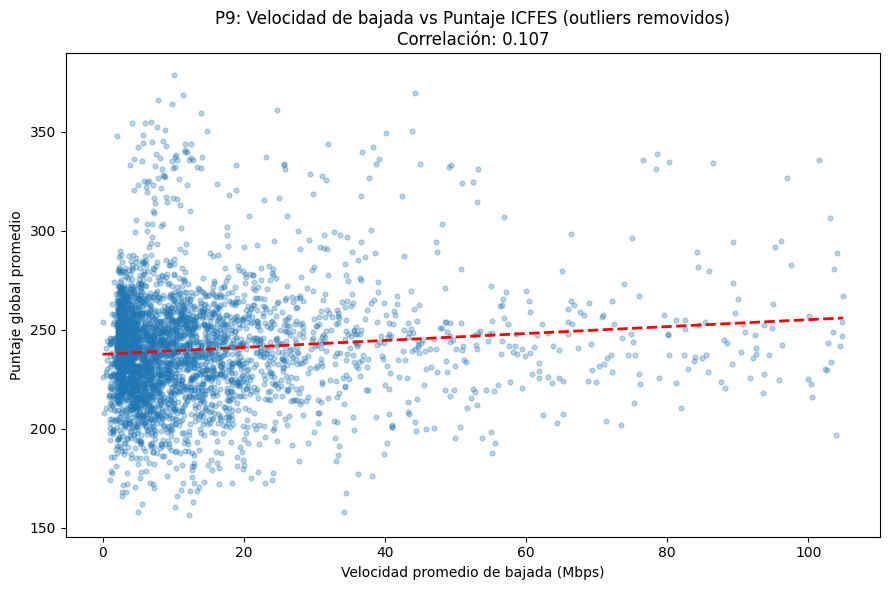

Correlación de Pearson (datos limpios): 0.1066


In [94]:
# Pregunta 9: ¿La velocidad de bajada se asocia al desempeño tras controlar outliers?
pdf = df_final.select("VEL_BAJADA_PROMEDIO", "PROM_PUNT_GLOBAL").dropna().toPandas()

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(pdf["VEL_BAJADA_PROMEDIO"], pdf["PROM_PUNT_GLOBAL"], alpha=0.3, s=12)
z = np.polyfit(pdf["VEL_BAJADA_PROMEDIO"], pdf["PROM_PUNT_GLOBAL"], 1)
p_fit = np.poly1d(z)
x_line = np.linspace(pdf["VEL_BAJADA_PROMEDIO"].min(), pdf["VEL_BAJADA_PROMEDIO"].max(), 200)
ax.plot(x_line, p_fit(x_line), "r--", linewidth=2)
corr = pdf["VEL_BAJADA_PROMEDIO"].corr(pdf["PROM_PUNT_GLOBAL"])
ax.set_title(f"P9: Velocidad de bajada vs Puntaje ICFES (outliers removidos)\nCorrelación: {corr:.3f}")
ax.set_xlabel("Velocidad promedio de bajada (Mbps)")
ax.set_ylabel("Puntaje global promedio")
plt.tight_layout()
plt.savefig("outputs_e2/plots/p9_velocidad_vs_puntaje_limpia.png", dpi=150)
plt.show()
print(f"Correlación de Pearson (datos limpios): {corr:.4f}")

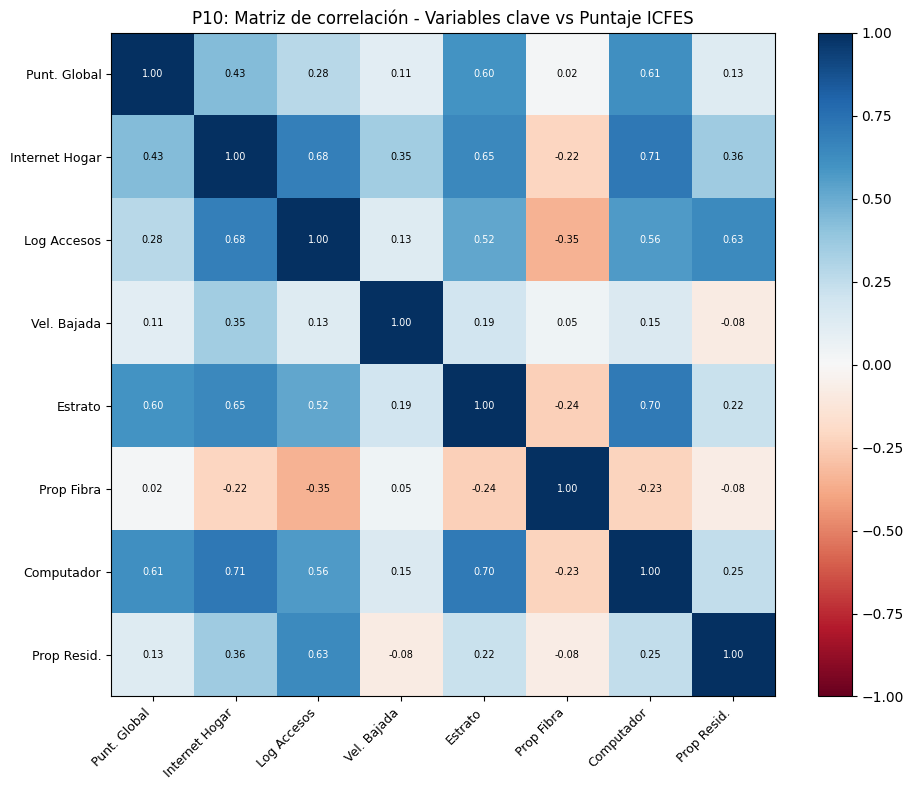

Correlaciones con PROM_PUNT_GLOBAL:
PROP_COMPUTADOR        0.609526
ESTRATO_PROMEDIO       0.599168
PROP_INTERNET_HOGAR    0.434106
LOG_TOTAL_ACCESOS      0.280803
PROP_RESIDENCIAL       0.127044
VEL_BAJADA_PROMEDIO    0.107985
PROP_FIBRA             0.021474
Name: PROM_PUNT_GLOBAL, dtype: float64


In [95]:
# Pregunta 10: ¿Qué variables son más predictivas del puntaje global?
# Se responde con los coeficientes del modelo de regresión (ver sección 5)
# Esta celda genera la matriz de correlación preliminar
vars_interes = [
    "PROM_PUNT_GLOBAL", "PROP_INTERNET_HOGAR", "LOG_TOTAL_ACCESOS",
    "VEL_BAJADA_PROMEDIO", "ESTRATO_PROMEDIO", "PROP_FIBRA",
    "PROP_COMPUTADOR", "PROP_RESIDENCIAL"
]

pdf = df_final.select(vars_interes).dropna().toPandas()
corr_matrix = pdf.corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix, cmap="RdBu", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(vars_interes)))
ax.set_yticks(range(len(vars_interes)))
etiquetas = ["Punt. Global", "Internet Hogar", "Log Accesos",
             "Vel. Bajada", "Estrato", "Prop Fibra", "Computador", "Prop Resid."]
ax.set_xticklabels(etiquetas, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(etiquetas, fontsize=9)
for i in range(len(vars_interes)):
    for j in range(len(vars_interes)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                ha="center", va="center", fontsize=7,
                color="white" if abs(corr_matrix.iloc[i, j]) > 0.5 else "black")
ax.set_title("P10: Matriz de correlación - Variables clave vs Puntaje ICFES")
plt.tight_layout()
plt.savefig("outputs_e2/plots/p10_correlacion_matriz.png", dpi=150)
plt.show()
print("Correlaciones con PROM_PUNT_GLOBAL:")
print(corr_matrix["PROM_PUNT_GLOBAL"].drop("PROM_PUNT_GLOBAL").sort_values(ascending=False))

---
## 3. Selección de Técnicas de Aprendizaje de Máquina

**Supervisado → Regresión Lineal (MLlib):**  
Se usa para predecir el puntaje global promedio municipal (`PROM_PUNT_GLOBAL`) a partir de variables de conectividad y contexto socioeconómico. Es interpretable: los coeficientes del modelo indican directamente el peso de cada variable, lo cual es valioso para orientar política pública.

**No supervisado → K-Means (MLlib):**  
Se usa para agrupar municipios según su perfil de conectividad y desempeño académico. El objetivo es identificar clústeres territoriales que concentren municipios con características similares, permitiendo al Ministerio priorizar intervenciones diferenciadas por perfil.

---
## 4. Preparación de Datos para Modelado

Para el modelado se construyeron dos bases de trabajo: una para regresión lineal supervisada y otra para agrupamiento no supervisado mediante K-Means. En la regresión lineal se excluyeron los puntajes por área para evitar fuga de información, debido a que estos hacen parte directa del puntaje global. La selección final de variables combina criterios estadísticos y de negocio, priorizando variables de conectividad, acceso en el hogar, disponibilidad tecnológica y condiciones socioeconómicas.

Antes de aplicar los modelos se revisó la correlación entre variables candidatas, se descartaron variables redundantes y se normalizaron las variables numéricas mediante `StandardScaler`, especialmente porque K-Means depende de distancias y puede verse afectado por diferencias de escala.

In [96]:
from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import RegressionEvaluator, ClusteringEvaluator
from pyspark.ml import Pipeline
from pyspark.sql import functions as F
import pandas as pd
import numpy as np

variables_candidatas_corr = [
    "PROM_PUNT_GLOBAL",
    "PROP_INTERNET_HOGAR",
    "PROP_COMPUTADOR",
    "ESTRATO_PROMEDIO",
    "EDAD_PROMEDIO",
    "PROP_HOMBRES",
    "LOG_TOTAL_ACCESOS",
    "LOG_ACCESOS_RESIDENCIAL",
    "VEL_BAJADA_PROMEDIO",
    "VEL_SUBIDA_PROMEDIO",
    "PROP_RESIDENCIAL",
    "PROP_CORPORATIVO",
    "PROP_FIBRA",
    "PROP_CABLE",
    "PROP_XDSL",
    "PROP_INALAMBRICA",
    "INDICE_CONECTIVIDAD"
]

df_corr = df_final.select(
    [F.col(c).cast("double").alias(c) for c in variables_candidatas_corr]
).dropna()

assembler_corr = VectorAssembler(
    inputCols=variables_candidatas_corr,
    outputCol="features_corr",
    handleInvalid="skip"
)

df_corr_vector = assembler_corr.transform(df_corr).select("features_corr")
matriz_corr = Correlation.corr(df_corr_vector, "features_corr", "pearson").collect()[0][0].toArray()

corr_df = pd.DataFrame(
    matriz_corr,
    index=variables_candidatas_corr,
    columns=variables_candidatas_corr
)

pares_altos = []

for i in range(len(variables_candidatas_corr)):
    for j in range(i + 1, len(variables_candidatas_corr)):
        corr_val = matriz_corr[i, j]
        if abs(corr_val) >= 0.85:
            pares_altos.append({
                "VARIABLE_1": variables_candidatas_corr[i],
                "VARIABLE_2": variables_candidatas_corr[j],
                "CORRELACION": corr_val
            })

pares_altos_df = pd.DataFrame(pares_altos)

corr_df.to_csv("outputs_e2/tables/mlib_matriz_correlacion.csv")
pares_altos_df.to_csv("outputs_e2/tables/mlib_variables_altamente_correlacionadas.csv", index=False)

print("Matriz de correlación calculada correctamente.")
print("Pares con correlación absoluta mayor o igual a 0.85:")

if len(pares_altos_df) > 0:
    print(pares_altos_df.to_string(index=False))
else:
    print("No se encontraron pares altamente correlacionados bajo el umbral definido.")

Matriz de correlación calculada correctamente.
Pares con correlación absoluta mayor o igual a 0.85:
       VARIABLE_1              VARIABLE_2  CORRELACION
LOG_TOTAL_ACCESOS LOG_ACCESOS_RESIDENCIAL     0.973415
 PROP_RESIDENCIAL        PROP_CORPORATIVO    -0.897755


In [97]:
variables_regresion = [
    "PROP_INTERNET_HOGAR",
    "PROP_COMPUTADOR",
    "ESTRATO_PROMEDIO",
    "EDAD_PROMEDIO",
    "PROP_HOMBRES",
    "INDICE_CONECTIVIDAD",
    "PROP_RESIDENCIAL",
    "PROP_CABLE",
    "PROP_XDSL",
    "PROP_INALAMBRICA"
]

variables_kmeans = [
    "PROM_PUNT_GLOBAL",
    "PROP_INTERNET_HOGAR",
    "PROP_COMPUTADOR",
    "ESTRATO_PROMEDIO",
    "INDICE_CONECTIVIDAD",
    "PROP_RESIDENCIAL",
    "PROP_CABLE",
    "PROP_INALAMBRICA"
]

df_regresion = df_final.select(
    [F.col("PROM_PUNT_GLOBAL").cast("double").alias("PROM_PUNT_GLOBAL")] +
    [F.col(c).cast("double").alias(c) for c in variables_regresion]
).dropna()

df_clustering = df_final.select(
    [F.col("COD_MUNICIPIO"), F.col("AÑO"), F.col("TRIMESTRE")] +
    [F.col(c).cast("double").alias(c) for c in variables_kmeans]
).dropna()

print(f"Registros para regresión lineal: {df_regresion.count()}")
print(f"Registros para K-Means: {df_clustering.count()}")

print("Variables finales para regresión lineal:")
print(variables_regresion)

print("Variables finales para K-Means:")
print(variables_kmeans)

Registros para regresión lineal: 3649
Registros para K-Means: 3652
Variables finales para regresión lineal:
['PROP_INTERNET_HOGAR', 'PROP_COMPUTADOR', 'ESTRATO_PROMEDIO', 'EDAD_PROMEDIO', 'PROP_HOMBRES', 'INDICE_CONECTIVIDAD', 'PROP_RESIDENCIAL', 'PROP_CABLE', 'PROP_XDSL', 'PROP_INALAMBRICA']
Variables finales para K-Means:
['PROM_PUNT_GLOBAL', 'PROP_INTERNET_HOGAR', 'PROP_COMPUTADOR', 'ESTRATO_PROMEDIO', 'INDICE_CONECTIVIDAD', 'PROP_RESIDENCIAL', 'PROP_CABLE', 'PROP_INALAMBRICA']


---
## 5. Modelo Supervisado: Regresión Lineal con MLlib

La regresión lineal se aplicó para predecir el puntaje global promedio municipal (`PROM_PUNT_GLOBAL`) a partir de variables de conectividad, acceso tecnológico en el hogar y condiciones socioeconómicas. Se usó una partición 80/20 entre entrenamiento y prueba, normalización de variables numéricas y comparación de diferentes configuraciones de regularización para evaluar el desempeño del modelo.

In [98]:
train_lr, test_lr = df_regresion.randomSplit([0.8, 0.2], seed=42)

parametros_lr = [
    (0.0, 0.0),
    (0.01, 0.0),
    (0.05, 0.0),
    (0.1, 0.0),
    (0.01, 0.5),
    (0.05, 0.5),
    (0.1, 0.5),
    (0.01, 1.0),
    (0.05, 1.0),
    (0.1, 1.0)
]

resultados_lr_lista = []
modelos_lr = {}

for i, (reg_param, elastic_net) in enumerate(parametros_lr):
    assembler_lr = VectorAssembler(
        inputCols=variables_regresion,
        outputCol="features_raw",
        handleInvalid="skip"
    )

    scaler_lr = StandardScaler(
        inputCol="features_raw",
        outputCol="features",
        withMean=True,
        withStd=True
    )

    lr = LinearRegression(
        featuresCol="features",
        labelCol="PROM_PUNT_GLOBAL",
        predictionCol="PRED_PUNT_GLOBAL",
        regParam=reg_param,
        elasticNetParam=elastic_net,
        maxIter=100
    )

    pipeline_lr = Pipeline(stages=[assembler_lr, scaler_lr, lr])
    modelo_lr = pipeline_lr.fit(train_lr)
    pred_lr = modelo_lr.transform(test_lr)

    rmse = RegressionEvaluator(
        labelCol="PROM_PUNT_GLOBAL",
        predictionCol="PRED_PUNT_GLOBAL",
        metricName="rmse"
    ).evaluate(pred_lr)

    mae = RegressionEvaluator(
        labelCol="PROM_PUNT_GLOBAL",
        predictionCol="PRED_PUNT_GLOBAL",
        metricName="mae"
    ).evaluate(pred_lr)

    r2 = RegressionEvaluator(
        labelCol="PROM_PUNT_GLOBAL",
        predictionCol="PRED_PUNT_GLOBAL",
        metricName="r2"
    ).evaluate(pred_lr)

    resultados_lr_lista.append({
        "MODELO_ID": i,
        "REG_PARAM": reg_param,
        "ELASTIC_NET_PARAM": elastic_net,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

    modelos_lr[i] = modelo_lr

resultados_lr = pd.DataFrame(resultados_lr_lista).sort_values("RMSE").reset_index(drop=True)
resultados_lr.to_csv("outputs_e2/tables/mlib_resultados_regresion_lineal.csv", index=False)

mejor_id_lr = int(resultados_lr.loc[0, "MODELO_ID"])
mejor_modelo_lr = modelos_lr[mejor_id_lr]
predicciones_lr = mejor_modelo_lr.transform(test_lr)

modelo_final_lr = mejor_modelo_lr.stages[-1]

coeficientes_lr = pd.DataFrame({
    "VARIABLE": variables_regresion,
    "COEFICIENTE_ESTANDARIZADO": [float(c) for c in modelo_final_lr.coefficients]
})

coeficientes_lr["ABS_COEFICIENTE"] = coeficientes_lr["COEFICIENTE_ESTANDARIZADO"].abs()
coeficientes_lr = coeficientes_lr.sort_values("ABS_COEFICIENTE", ascending=False)

coeficientes_lr.to_csv("outputs_e2/tables/mlib_coeficientes_regresion_lineal.csv", index=False)

print("Resultados de modelos de regresión lineal:")
print(resultados_lr.to_string(index=False))

print("\nMejor modelo de regresión lineal:")
print(resultados_lr.iloc[0].to_string())

print("\nIntercepto:")
print(modelo_final_lr.intercept)

print("\nCoeficientes estandarizados:")
print(coeficientes_lr[["VARIABLE", "COEFICIENTE_ESTANDARIZADO"]].to_string(index=False))

print("\nPredicciones de ejemplo:")
predicciones_lr.select(
    "PROM_PUNT_GLOBAL",
    "PRED_PUNT_GLOBAL",
    "PROP_INTERNET_HOGAR",
    "PROP_COMPUTADOR",
    "ESTRATO_PROMEDIO",
    "INDICE_CONECTIVIDAD"
).show(10, truncate=False)

Resultados de modelos de regresión lineal:
 MODELO_ID  REG_PARAM  ELASTIC_NET_PARAM      RMSE       MAE       R2
         7       0.01                1.0 21.179785 16.885281 0.443789
         8       0.05                1.0 21.186245 16.889477 0.401633
         9       0.10                1.0 21.346960 16.855425 0.406442
         4       0.01                0.5 22.525418 16.839292 0.406650
         6       0.10                0.5 22.619060 16.891466 0.401706
         3       0.10                0.0 22.619134 16.303379 0.401703
         5       0.05                0.5 22.620514 16.887859 0.443575
         2       0.05                0.0 22.620944 16.886245 0.443674
         1       0.01                0.0 22.622530 16.290559 0.401523
         0       0.00                0.0 22.622947 16.884231 0.401501

Mejor modelo de regresión lineal:
MODELO_ID             7.000000
REG_PARAM             0.010000
ELASTIC_NET_PARAM     1.000000
RMSE                 21.179785
MAE                  16.8852

---
## 6. Modelo No Supervisado: K-Means con MLlib

K-Means se aplicó para identificar perfiles territoriales de municipios-periodo según desempeño académico, conectividad, acceso tecnológico en el hogar y características socioeconómicas. Se probaron diferentes valores de `k` y se seleccionó la configuración con mejor métrica de silueta, interpretando posteriormente los clústeres a partir de sus promedios por variable.

In [99]:
valores_k = [2, 3, 4, 5, 6, 7]

resultados_kmeans_lista = []
modelos_kmeans = {}

for i, k in enumerate(valores_k):
    assembler_km = VectorAssembler(
        inputCols=variables_kmeans,
        outputCol="features_raw",
        handleInvalid="skip"
    )

    scaler_km = StandardScaler(
        inputCol="features_raw",
        outputCol="features",
        withMean=True,
        withStd=True
    )

    kmeans = KMeans(
        featuresCol="features",
        predictionCol="CLUSTER",
        k=k,
        seed=42,
        maxIter=100
    )

    pipeline_km = Pipeline(stages=[assembler_km, scaler_km, kmeans])
    modelo_km = pipeline_km.fit(df_clustering)
    pred_km = modelo_km.transform(df_clustering)

    silhouette = ClusteringEvaluator(
        featuresCol="features",
        predictionCol="CLUSTER",
        metricName="silhouette",
        distanceMeasure="squaredEuclidean"
    ).evaluate(pred_km)

    modelo_kmeans_final = modelo_km.stages[-1]
    costo = modelo_kmeans_final.summary.trainingCost

    resultados_kmeans_lista.append({
        "MODELO_ID": i,
        "K": k,
        "SILHOUETTE": silhouette,
        "TRAINING_COST": costo
    })

    modelos_kmeans[i] = modelo_km

resultados_kmeans = pd.DataFrame(resultados_kmeans_lista).sort_values("SILHOUETTE", ascending=False).reset_index(drop=True)
resultados_kmeans.to_csv("outputs_e2/tables/mlib_resultados_kmeans.csv", index=False)

mejor_id_kmeans = int(resultados_kmeans.loc[0, "MODELO_ID"])
mejor_modelo_kmeans = modelos_kmeans[mejor_id_kmeans]
predicciones_kmeans = mejor_modelo_kmeans.transform(df_clustering)

perfil_clusters = predicciones_kmeans.groupBy("CLUSTER").agg(
    F.count("*").alias("N_OBS"),
    *[F.round(F.avg(c), 4).alias(f"{c}_PROM") for c in variables_kmeans]
).orderBy("CLUSTER")

perfil_clusters_pd = perfil_clusters.toPandas()
perfil_clusters_pd.to_csv("outputs_e2/tables/mlib_perfil_clusters_kmeans.csv", index=False)

predicciones_kmeans.select(
    "COD_MUNICIPIO",
    "AÑO",
    "TRIMESTRE",
    "CLUSTER",
    *variables_kmeans
).toPandas().to_csv("outputs_e2/tables/mlib_asignacion_clusters_kmeans.csv", index=False)

print("Resultados de K-Means:")
print(resultados_kmeans.to_string(index=False))

print("\nMejor modelo K-Means:")
print(resultados_kmeans.iloc[0].to_string())

print("\nPerfil promedio de los clústeres:")
print(perfil_clusters_pd.to_string(index=False))

Resultados de K-Means:
 MODELO_ID  K  SILHOUETTE  TRAINING_COST
         0  2    0.612218   20660.273931
         3  5    0.419451   12487.284437
         2  4    0.397579   14671.320904
         5  7    0.383009   10562.680882
         4  6    0.365800   11339.203136
         1  3    0.363326   17163.150005

Mejor modelo K-Means:
MODELO_ID            0.000000
K                    2.000000
SILHOUETTE           0.612218
TRAINING_COST    20660.273931

Perfil promedio de los clústeres:
 CLUSTER  N_OBS  PROM_PUNT_GLOBAL_PROM  PROP_INTERNET_HOGAR_PROM  PROP_COMPUTADOR_PROM  ESTRATO_PROMEDIO_PROM  INDICE_CONECTIVIDAD_PROM  PROP_RESIDENCIAL_PROM  PROP_CABLE_PROM  PROP_INALAMBRICA_PROM
       0   3094               234.5511                    0.3423                0.3466                 1.5921                    0.2932                 0.6980           0.0452                 0.2286
       1    558               270.8537                    0.8233                0.7570                 2.7331     

In [100]:
total_kmeans = perfil_clusters_pd["N_OBS"].sum()

perfil_clusters_pd["PORCENTAJE"] = (perfil_clusters_pd["N_OBS"] / total_kmeans * 100).round(2)

perfil_clusters_pd["PERFIL_TERRITORIAL"] = perfil_clusters_pd["CLUSTER"].map({
    0: "Perfil rezagado en desempeño, acceso tecnológico y conectividad",
    1: "Perfil favorable en desempeño, acceso tecnológico y conectividad"
})

perfil_clusters_reporte = perfil_clusters_pd[
    [
        "CLUSTER",
        "PERFIL_TERRITORIAL",
        "N_OBS",
        "PORCENTAJE",
        "PROM_PUNT_GLOBAL_PROM",
        "PROP_INTERNET_HOGAR_PROM",
        "PROP_COMPUTADOR_PROM",
        "ESTRATO_PROMEDIO_PROM",
        "INDICE_CONECTIVIDAD_PROM",
        "PROP_RESIDENCIAL_PROM",
        "PROP_CABLE_PROM",
        "PROP_INALAMBRICA_PROM"
    ]
]

print("Perfil final de clústeres para el informe:")
print(perfil_clusters_reporte.to_string(index=False))

diferencias_clusters = {
    "DIF_PUNTAJE_GLOBAL": perfil_clusters_pd.loc[perfil_clusters_pd["CLUSTER"] == 1, "PROM_PUNT_GLOBAL_PROM"].iloc[0] - perfil_clusters_pd.loc[perfil_clusters_pd["CLUSTER"] == 0, "PROM_PUNT_GLOBAL_PROM"].iloc[0],
    "DIF_INTERNET_HOGAR": perfil_clusters_pd.loc[perfil_clusters_pd["CLUSTER"] == 1, "PROP_INTERNET_HOGAR_PROM"].iloc[0] - perfil_clusters_pd.loc[perfil_clusters_pd["CLUSTER"] == 0, "PROP_INTERNET_HOGAR_PROM"].iloc[0],
    "DIF_COMPUTADOR": perfil_clusters_pd.loc[perfil_clusters_pd["CLUSTER"] == 1, "PROP_COMPUTADOR_PROM"].iloc[0] - perfil_clusters_pd.loc[perfil_clusters_pd["CLUSTER"] == 0, "PROP_COMPUTADOR_PROM"].iloc[0],
    "DIF_ESTRATO": perfil_clusters_pd.loc[perfil_clusters_pd["CLUSTER"] == 1, "ESTRATO_PROMEDIO_PROM"].iloc[0] - perfil_clusters_pd.loc[perfil_clusters_pd["CLUSTER"] == 0, "ESTRATO_PROMEDIO_PROM"].iloc[0],
    "DIF_INDICE_CONECTIVIDAD": perfil_clusters_pd.loc[perfil_clusters_pd["CLUSTER"] == 1, "INDICE_CONECTIVIDAD_PROM"].iloc[0] - perfil_clusters_pd.loc[perfil_clusters_pd["CLUSTER"] == 0, "INDICE_CONECTIVIDAD_PROM"].iloc[0],
    "DIF_PROP_CABLE": perfil_clusters_pd.loc[perfil_clusters_pd["CLUSTER"] == 1, "PROP_CABLE_PROM"].iloc[0] - perfil_clusters_pd.loc[perfil_clusters_pd["CLUSTER"] == 0, "PROP_CABLE_PROM"].iloc[0],
    "DIF_PROP_INALAMBRICA": perfil_clusters_pd.loc[perfil_clusters_pd["CLUSTER"] == 1, "PROP_INALAMBRICA_PROM"].iloc[0] - perfil_clusters_pd.loc[perfil_clusters_pd["CLUSTER"] == 0, "PROP_INALAMBRICA_PROM"].iloc[0]
}

diferencias_clusters_df = pd.DataFrame([diferencias_clusters]).round(4)

print("\nDiferencias principales entre el clúster 1 y el clúster 0:")
print(diferencias_clusters_df.to_string(index=False))

Perfil final de clústeres para el informe:
 CLUSTER                                               PERFIL_TERRITORIAL  N_OBS  PORCENTAJE  PROM_PUNT_GLOBAL_PROM  PROP_INTERNET_HOGAR_PROM  PROP_COMPUTADOR_PROM  ESTRATO_PROMEDIO_PROM  INDICE_CONECTIVIDAD_PROM  PROP_RESIDENCIAL_PROM  PROP_CABLE_PROM  PROP_INALAMBRICA_PROM
       0  Perfil rezagado en desempeño, acceso tecnológico y conectividad   3094       84.72               234.5511                    0.3423                0.3466                 1.5921                    0.2932                 0.6980           0.0452                 0.2286
       1 Perfil favorable en desempeño, acceso tecnológico y conectividad    558       15.28               270.8537                    0.8233                0.7570                 2.7331                    0.3683                 0.9055           0.5692                 0.0782

Diferencias principales entre el clúster 1 y el clúster 0:
 DIF_PUNTAJE_GLOBAL  DIF_INTERNET_HOGAR  DIF_COMPUTADOR  DIF_ESTRATO 

In [101]:
mejor_k = int(resultados_kmeans.iloc[0]["K"])
mejor_silhouette = float(resultados_kmeans.iloc[0]["SILHOUETTE"])
mejor_cost = float(resultados_kmeans.iloc[0]["TRAINING_COST"])

print(f"El mejor modelo K-Means fue el de K={mejor_k}, con una silueta de {mejor_silhouette:.4f} y un training cost de {mejor_cost:.4f}.")

if mejor_silhouette >= 0.5:
    print("La métrica de silueta indica una separación adecuada entre los clústeres.")
elif mejor_silhouette >= 0.25:
    print("La métrica de silueta indica una separación moderada entre los clústeres.")
else:
    print("La métrica de silueta indica una separación débil entre los clústeres.")

print("Aunque el training cost disminuye cuando aumenta K, se seleccionó el modelo con mayor silueta porque ofrece mejor separación e interpretación territorial.")

El mejor modelo K-Means fue el de K=2, con una silueta de 0.6122 y un training cost de 20660.2739.
La métrica de silueta indica una separación adecuada entre los clústeres.
Aunque el training cost disminuye cuando aumenta K, se seleccionó el modelo con mayor silueta porque ofrece mejor separación e interpretación territorial.


In [102]:
predicciones_kmeans_reporte = predicciones_kmeans.withColumn(
    "PERFIL_TERRITORIAL",
    F.when(
        F.col("CLUSTER") == 0,
        F.lit("Perfil rezagado en desempeño, acceso tecnológico y conectividad")
    ).otherwise(
        F.lit("Perfil favorable en desempeño, acceso tecnológico y conectividad")
    )
)

predicciones_kmeans_reporte.select(
    "COD_MUNICIPIO",
    "AÑO",
    "TRIMESTRE",
    "CLUSTER",
    "PERFIL_TERRITORIAL",
    "PROM_PUNT_GLOBAL",
    "PROP_INTERNET_HOGAR",
    "PROP_COMPUTADOR",
    "ESTRATO_PROMEDIO",
    "INDICE_CONECTIVIDAD"
).show(20, truncate=False)

+-------------+----+---------+-------+----------------------------------------------------------------+------------------+-------------------+-------------------+------------------+-------------------+
|COD_MUNICIPIO|AÑO |TRIMESTRE|CLUSTER|PERFIL_TERRITORIAL                                              |PROM_PUNT_GLOBAL  |PROP_INTERNET_HOGAR|PROP_COMPUTADOR    |ESTRATO_PROMEDIO  |INDICE_CONECTIVIDAD|
+-------------+----+---------+-------+----------------------------------------------------------------+------------------+-------------------+-------------------+------------------+-------------------+
|76001        |2019|4        |1      |Perfil favorable en desempeño, acceso tecnológico y conectividad|245.6882150394313 |0.8175054439874183 |0.6836997193638915 |2.139711696368834 |0.4478136211699496 |
|8141         |2019|4        |0      |Perfil rezagado en desempeño, acceso tecnológico y conectividad |206.8658536585366 |0.07894736842105263|0.22012578616352202|1.4933333333333334|0.145664846